In [2]:
import numpy as np
import pyEXP
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.pyplot import cm
import pandas as pd
from astropy.table import Table, vstack

from functools import partial
from matplotlib import animation
from matplotlib.animation import FuncAnimation
%matplotlib inline

import sys
sys.path.append('/mnt/home/ktavangar/projects/MSSA_Snails/code/')
import importlib
import helper

In [3]:
%config InlineBackend.figure_format = 'retina'
%matplotlib inline

plt.rcParams.update({
    'axes.linewidth': 2,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    "lines.color": "white",
    "patch.edgecolor": "white",
    "text.color": "black",
    "axes.facecolor": "white",
    "axes.edgecolor": "lightgray",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "grid.color": "lightgray",
    "figure.facecolor": "white",
    "figure.edgecolor": "white",
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white"})

## Look at Populations in Annuli at Different Times

In [4]:
importlib.reload(sys.modules['load_data_B2'])
from load_data_B2 import setup_B2, setup_B2_subset

data100 = setup_B2(100, actions_only=True, extras=True)
data150 = setup_B2(150, actions_only=True, extras=True)
data200 = setup_B2(200, actions_only=True, extras=True)
data250 = setup_B2(250, actions_only=True, extras=True)
data300 = setup_B2(300, actions_only=True, extras=True)
data350 = setup_B2(350, actions_only=True, extras=True)
data400 = setup_B2(400, actions_only=True, extras=True)
data450 = setup_B2(450, actions_only=True, extras=True)

Loading Actions...
Loading Actions...
Loading Actions...
Loading Actions...
Loading Actions...
Loading Actions...
Loading Actions...
Loading Actions...


In [5]:
outer100 = data100[(data100.jphi > 2000) & (data100.jphi < 3000)]
outer150 = data150[(data150.jphi > 2000) & (data150.jphi < 3000)]
outer200 = data200[(data200.jphi > 2000) & (data300.jphi < 3000)]
outer250 = data250[(data250.jphi > 2000) & (data250.jphi < 3000)]
outer300 = data300[(data300.jphi > 2000) & (data300.jphi < 3000)]
outer350 = data350[(data350.jphi > 2000) & (data350.jphi < 3000)]
outer400 = data400[(data400.jphi > 2000) & (data400.jphi < 3000)]
outer450 = data450[(data450.jphi > 2000) & (data450.jphi < 3000)]

In [6]:
outer_original150 = data150[(data100.jphi > 2000) & (data100.jphi < 3000)]
outer_original200 = data200[(data100.jphi > 2000) & (data100.jphi < 3000)]
outer_original250 = data250[(data100.jphi > 2000) & (data100.jphi < 3000)]
outer_original300 = data300[(data100.jphi > 2000) & (data100.jphi < 3000)]
outer_original350 = data350[(data100.jphi > 2000) & (data100.jphi < 3000)]
outer_original400 = data400[(data100.jphi > 2000) & (data100.jphi < 3000)]
outer_original450 = data450[(data100.jphi > 2000) & (data100.jphi < 3000)]

## Let's Make Some Histograms Before the Interaction

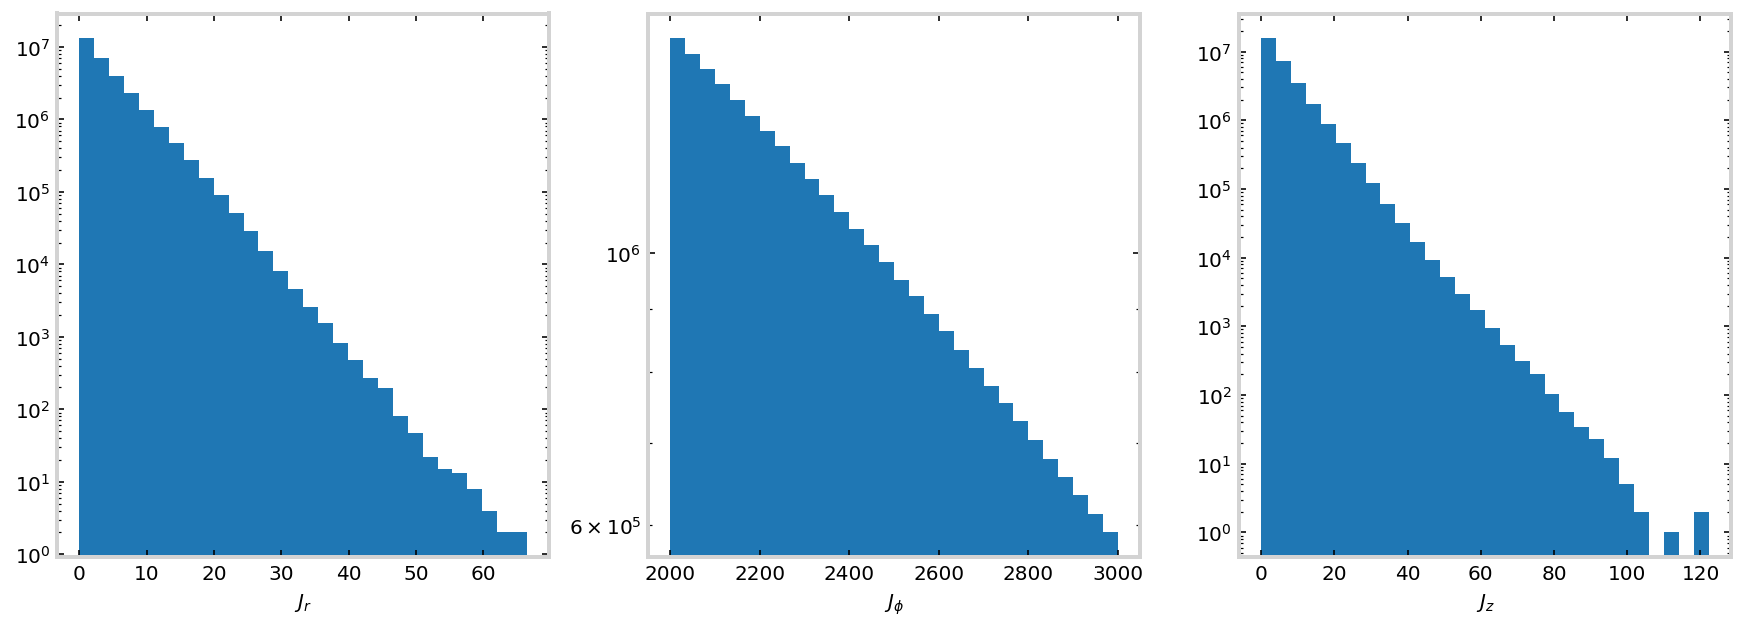

In [7]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist(outer100.jr, bins=30)
axs[0].set_xlabel(r'$J_r$')
axs[0].set_yscale('log')

axs[1].hist(outer100.jphi, bins=30)
axs[1].set_xlabel(r'$J_\phi$')
axs[1].set_yscale('log')

axs[2].hist(outer100.jz, bins=30)
axs[2].set_xlabel(r'$J_z$')
axs[2].set_yscale('log')
plt.show()

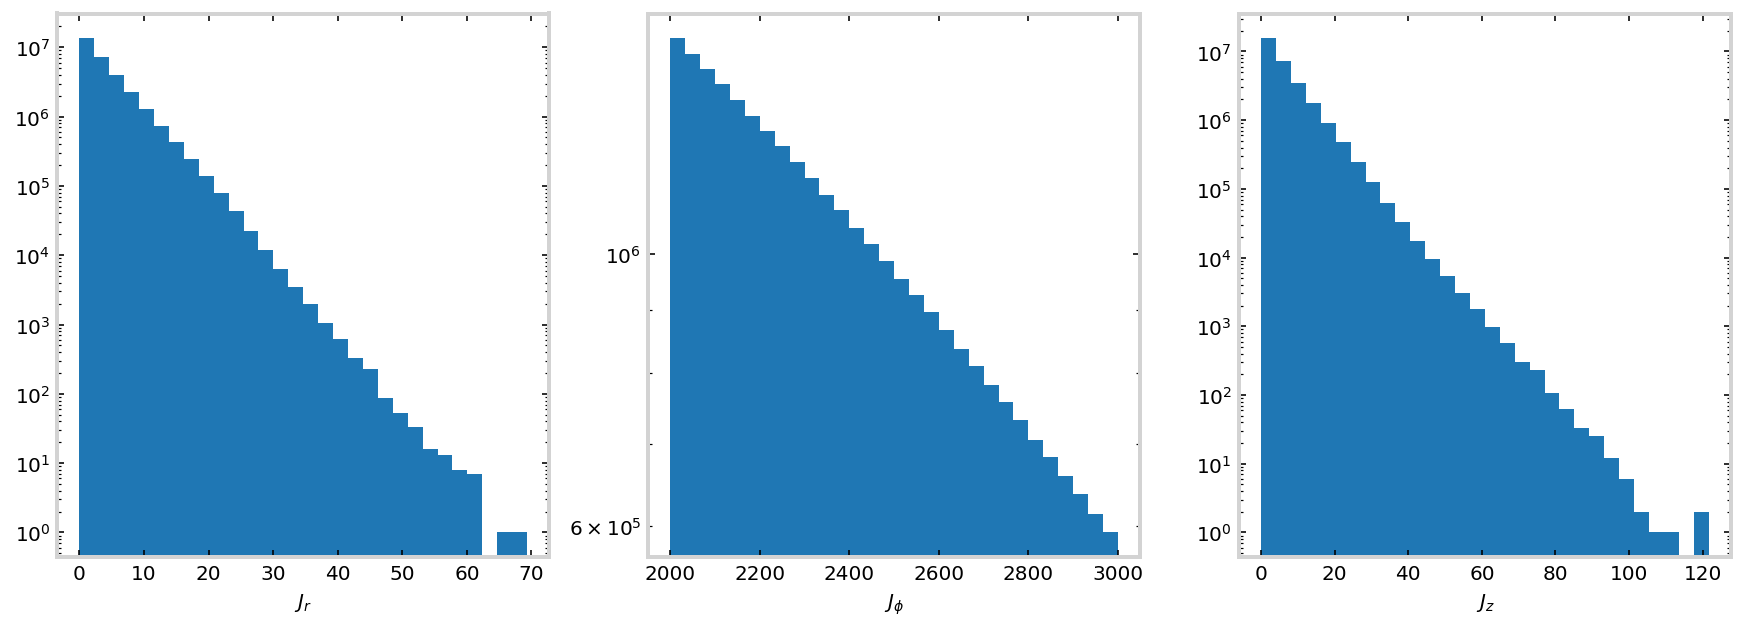

In [8]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist(outer150.jr, bins=30)
axs[0].set_xlabel(r'$J_r$')
axs[0].set_yscale('log')

axs[1].hist(outer150.jphi, bins=30)
axs[1].set_xlabel(r'$J_\phi$')
axs[1].set_yscale('log')

axs[2].hist(outer150.jz, bins=30)
axs[2].set_xlabel(r'$J_z$')
axs[2].set_yscale('log')
plt.show()

## Now Let's Plot $\Delta J$

These are histograms where I am subtracting the outer disk populations from one another at different times, but on a star-by-star basis, meaning that I am only seeing $\Delta J$ for stars that are in the outer disk $(2000 < J_{\phi} < 3000)$ in both timesteps

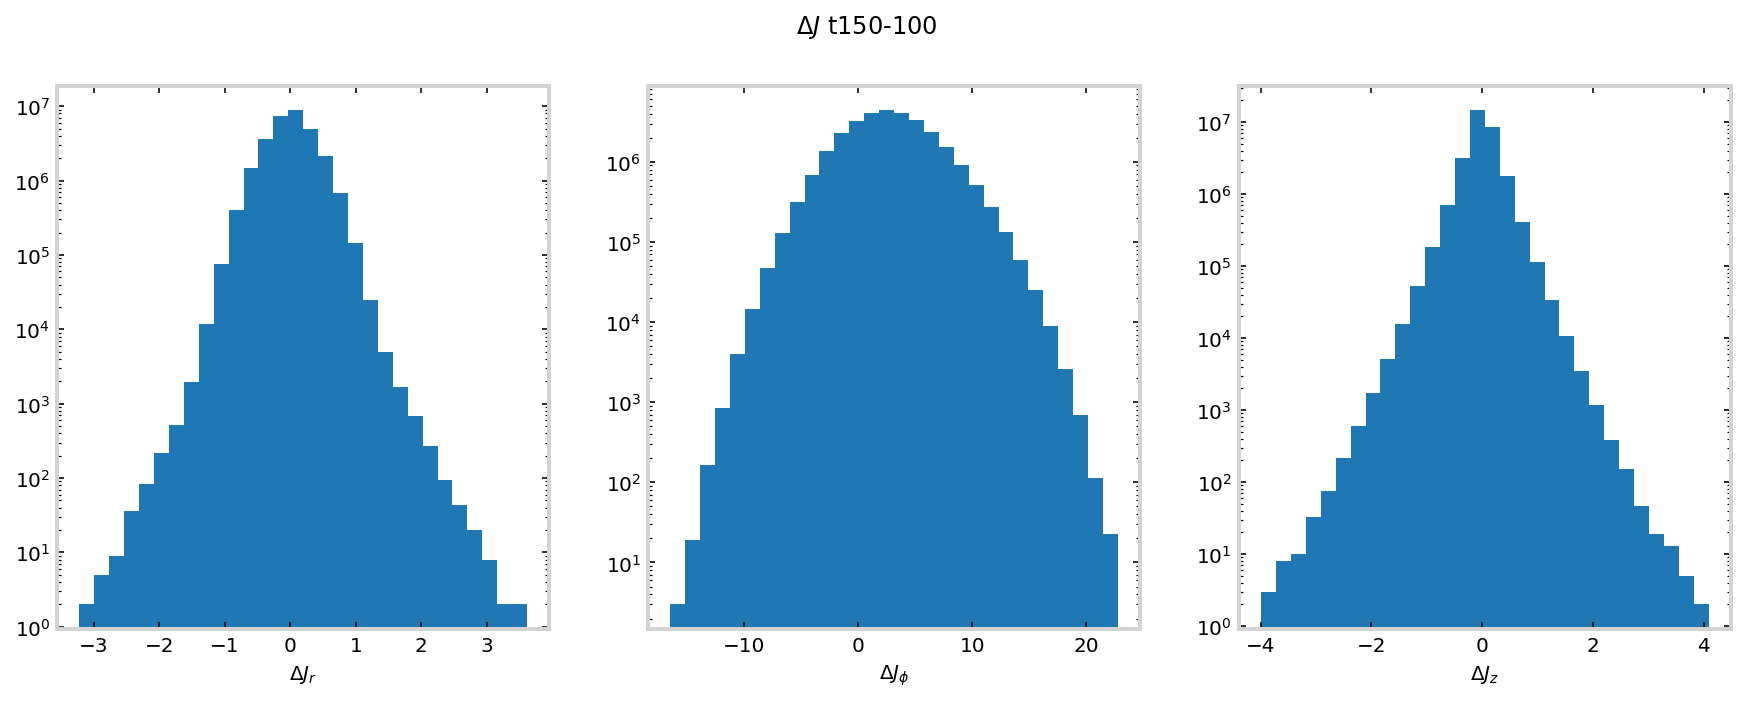

In [9]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist(outer150.jr - outer100.jr, bins=30)
axs[0].set_xlabel(r'$\Delta J_r$')
axs[0].set_yscale('log')

axs[1].hist(outer150.jphi - outer100.jphi, bins=30)
axs[1].set_xlabel(r'$\Delta J_\phi$')
axs[1].set_yscale('log')

axs[2].hist(outer150.jz - outer100.jz, bins=30)
axs[2].set_xlabel(r'$\Delta J_z$')
axs[2].set_yscale('log')
plt.suptitle(r'$\Delta J$ t150-100')
plt.show()

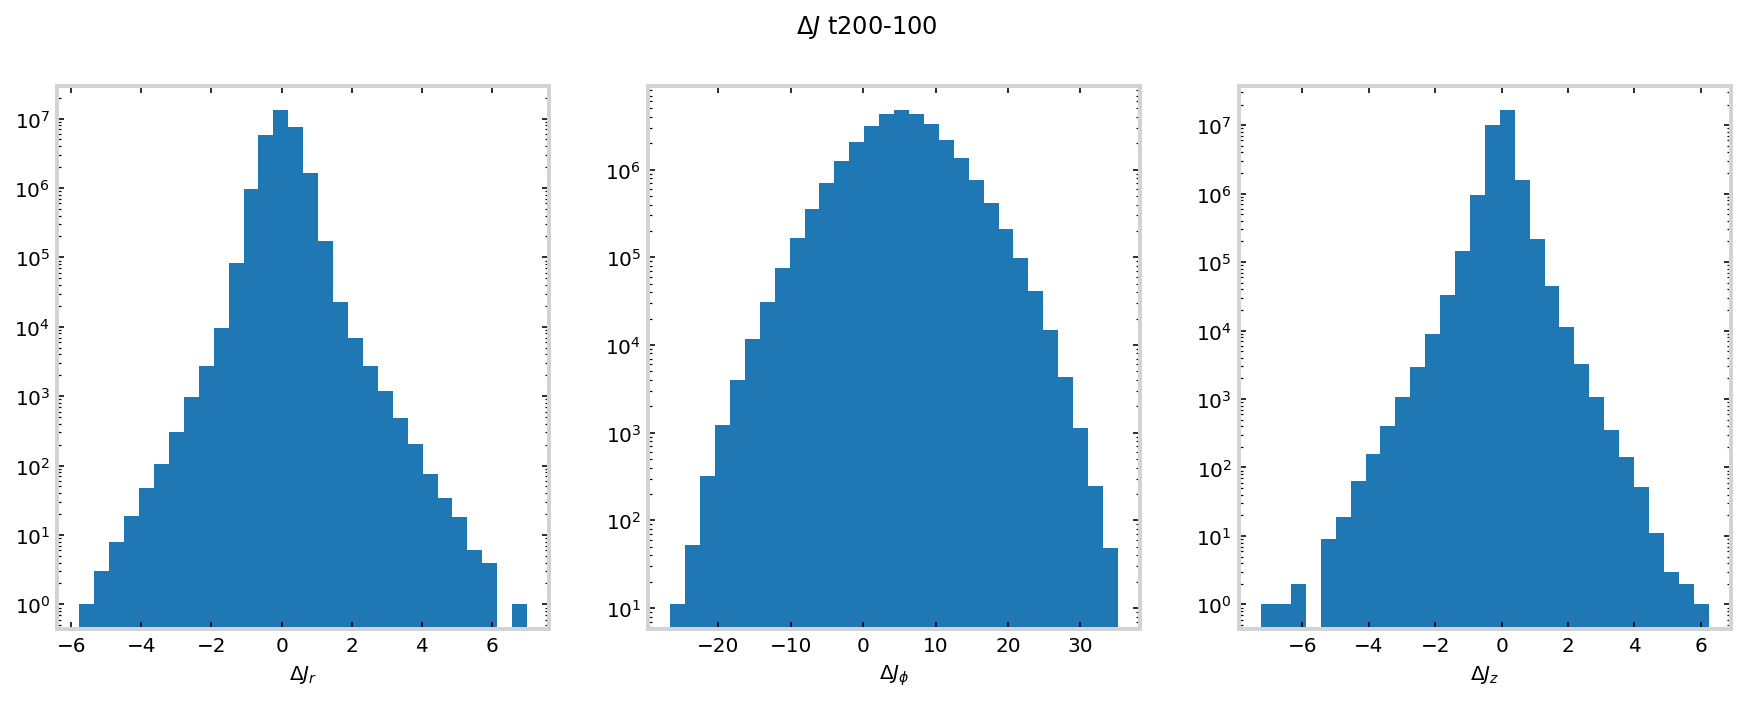

In [10]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist(outer200.jr - outer100.jr, bins=30)
axs[0].set_xlabel(r'$\Delta J_r$')
axs[0].set_yscale('log')

axs[1].hist(outer200.jphi - outer100.jphi, bins=30)
axs[1].set_xlabel(r'$\Delta J_\phi$')
axs[1].set_yscale('log')

axs[2].hist(outer200.jz - outer100.jz, bins=30)
axs[2].set_xlabel(r'$\Delta J_z$')
axs[2].set_yscale('log')
plt.suptitle(r'$\Delta J$ t200-100')
plt.show()

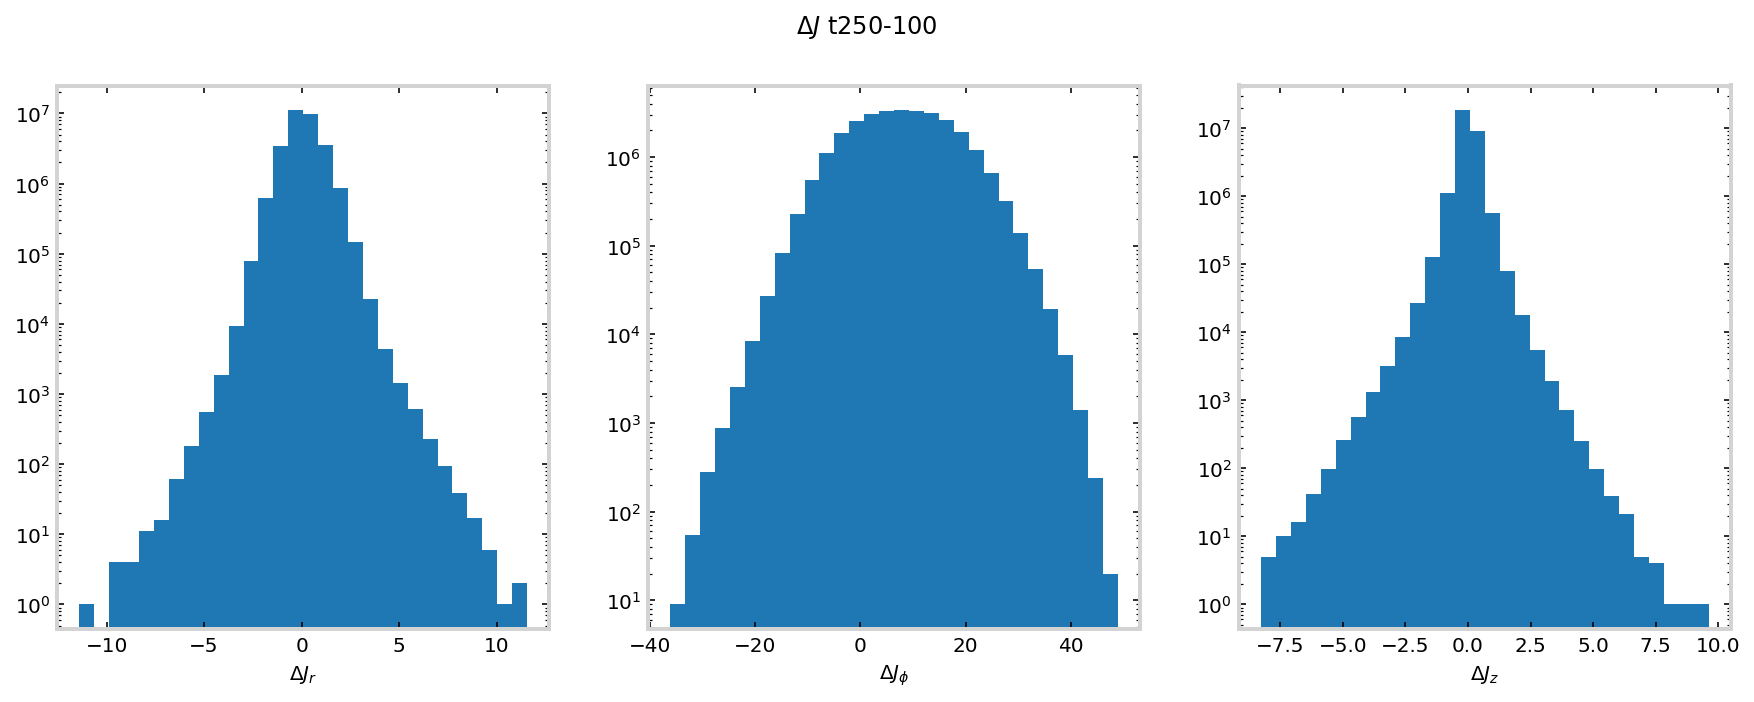

In [11]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist(outer250.jr - outer100.jr, bins=30)
axs[0].set_xlabel(r'$\Delta J_r$')
axs[0].set_yscale('log')

axs[1].hist(outer250.jphi - outer100.jphi, bins=30)
axs[1].set_xlabel(r'$\Delta J_\phi$')
axs[1].set_yscale('log')

axs[2].hist(outer250.jz - outer100.jz, bins=30)
axs[2].set_xlabel(r'$\Delta J_z$')
axs[2].set_yscale('log')
plt.suptitle(r'$\Delta J$ t250-100')
plt.show()

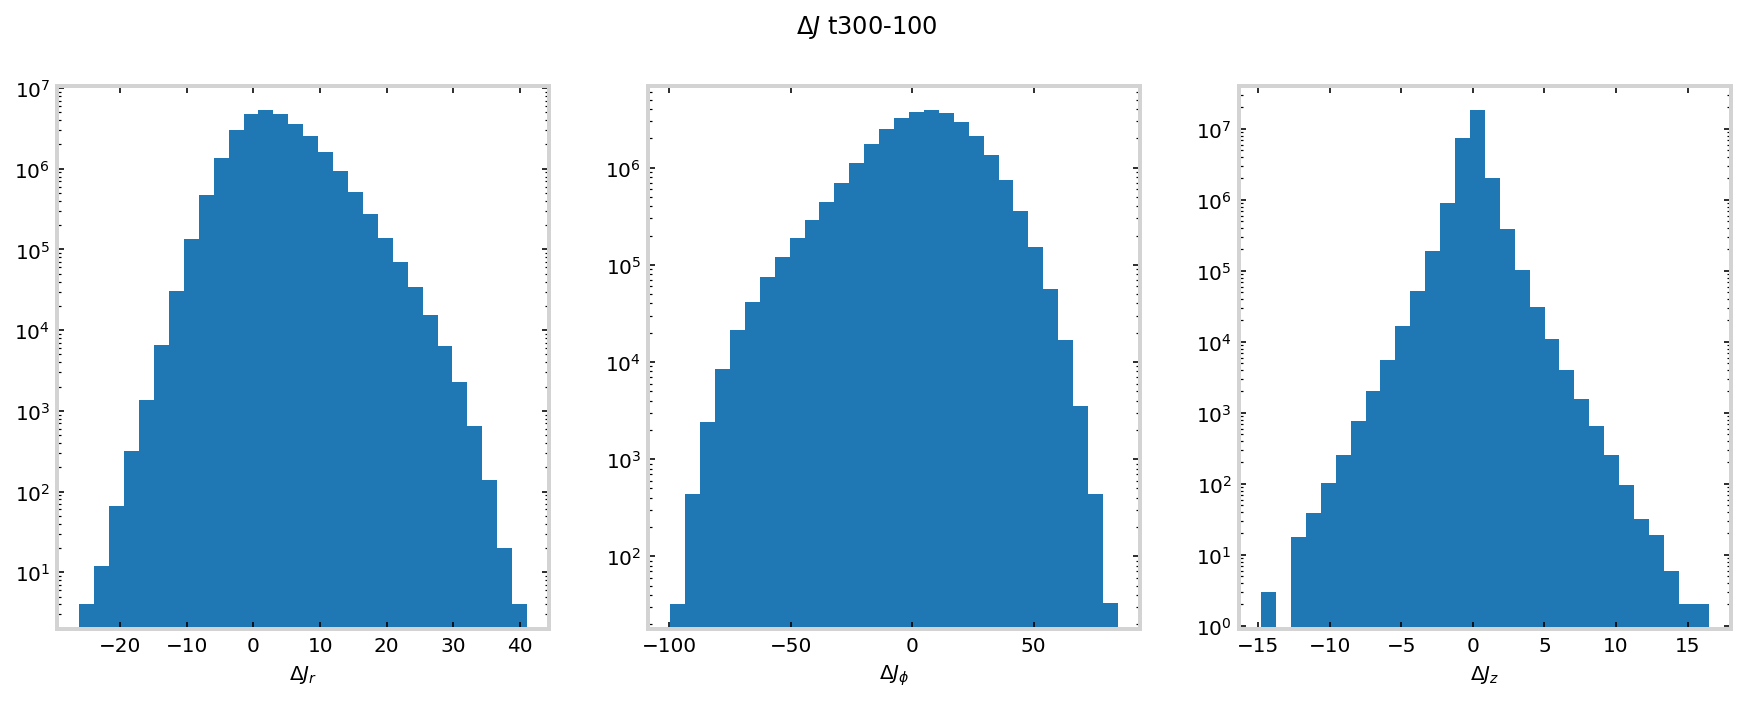

In [12]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist(outer300.jr - outer100.jr, bins=30)
axs[0].set_xlabel(r'$\Delta J_r$')
axs[0].set_yscale('log')

axs[1].hist(outer300.jphi - outer100.jphi, bins=30)
axs[1].set_xlabel(r'$\Delta J_\phi$')
axs[1].set_yscale('log')

axs[2].hist(outer300.jz - outer100.jz, bins=30)
axs[2].set_xlabel(r'$\Delta J_z$')
axs[2].set_yscale('log')
plt.suptitle(r'$\Delta J$ t300-100')
plt.show()

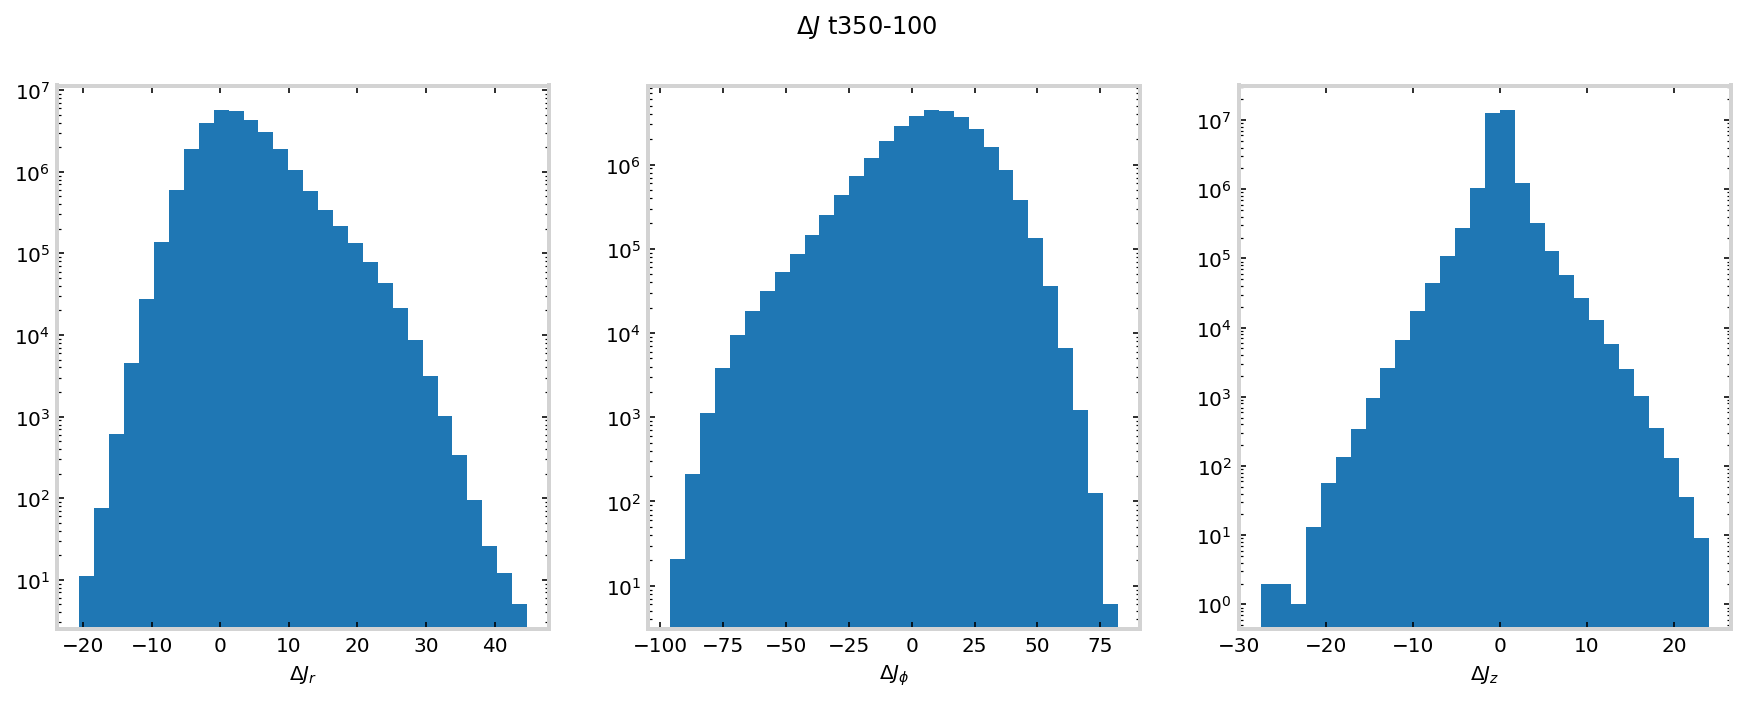

In [13]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist(outer350.jr - outer100.jr, bins=30)
axs[0].set_xlabel(r'$\Delta J_r$')
axs[0].set_yscale('log')

axs[1].hist(outer350.jphi - outer100.jphi, bins=30)
axs[1].set_xlabel(r'$\Delta J_\phi$')
axs[1].set_yscale('log')

axs[2].hist(outer350.jz - outer100.jz, bins=30)
axs[2].set_xlabel(r'$\Delta J_z$')
axs[2].set_yscale('log')
plt.suptitle(r'$\Delta J$ t350-100')
plt.show()

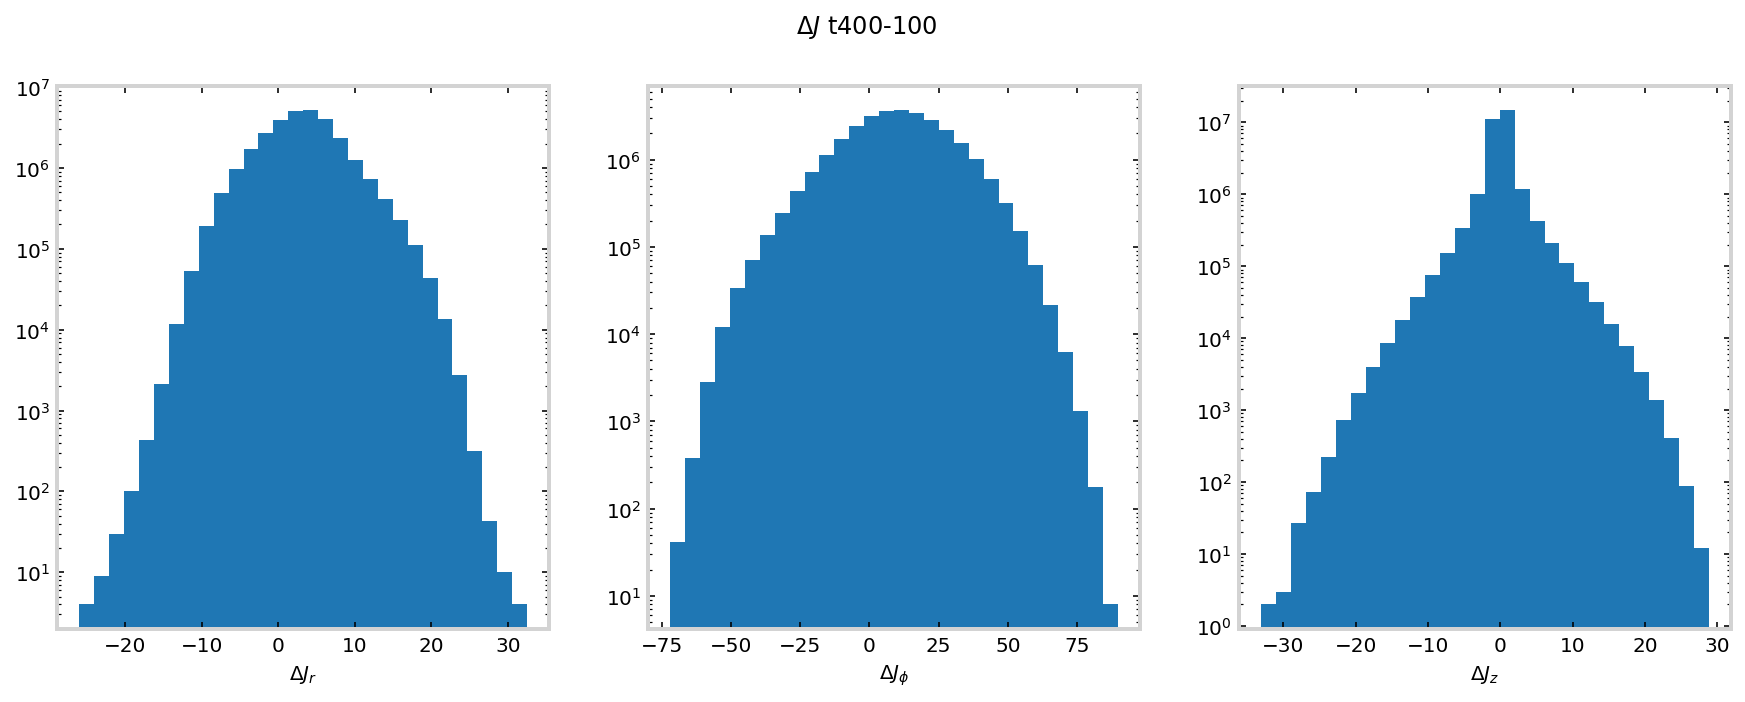

In [14]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist(outer400.jr - outer100.jr, bins=30)
axs[0].set_xlabel(r'$\Delta J_r$')
axs[0].set_yscale('log')

axs[1].hist(outer400.jphi - outer100.jphi, bins=30)
axs[1].set_xlabel(r'$\Delta J_\phi$')
axs[1].set_yscale('log')

axs[2].hist(outer400.jz - outer100.jz, bins=30)
axs[2].set_xlabel(r'$\Delta J_z$')
axs[2].set_yscale('log')
plt.suptitle(r'$\Delta J$ t400-100')
plt.show()

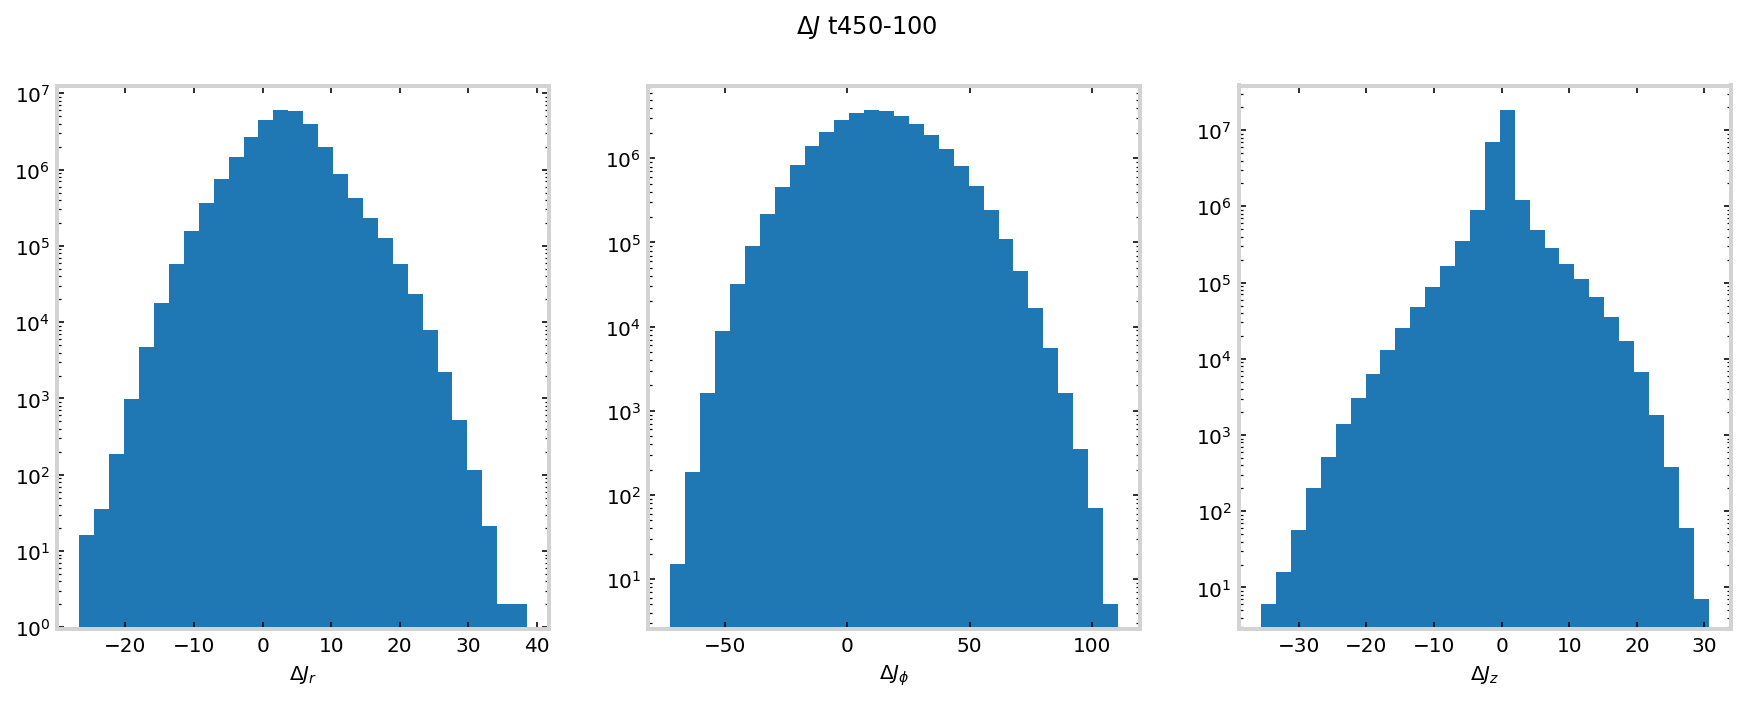

In [15]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist(outer450.jr - outer100.jr, bins=30)
axs[0].set_xlabel(r'$\Delta J_r$')
axs[0].set_yscale('log')

axs[1].hist(outer450.jphi - outer100.jphi, bins=30)
axs[1].set_xlabel(r'$\Delta J_\phi$')
axs[1].set_yscale('log')

axs[2].hist(outer450.jz - outer100.jz, bins=30)
axs[2].set_xlabel(r'$\Delta J_z$')
axs[2].set_yscale('log')
plt.suptitle(r'$\Delta J$ t450-100')
plt.show()

The other histograms I can make are $\Delta J$ for any stars that were originally in the outer disk, no matter where they are now:

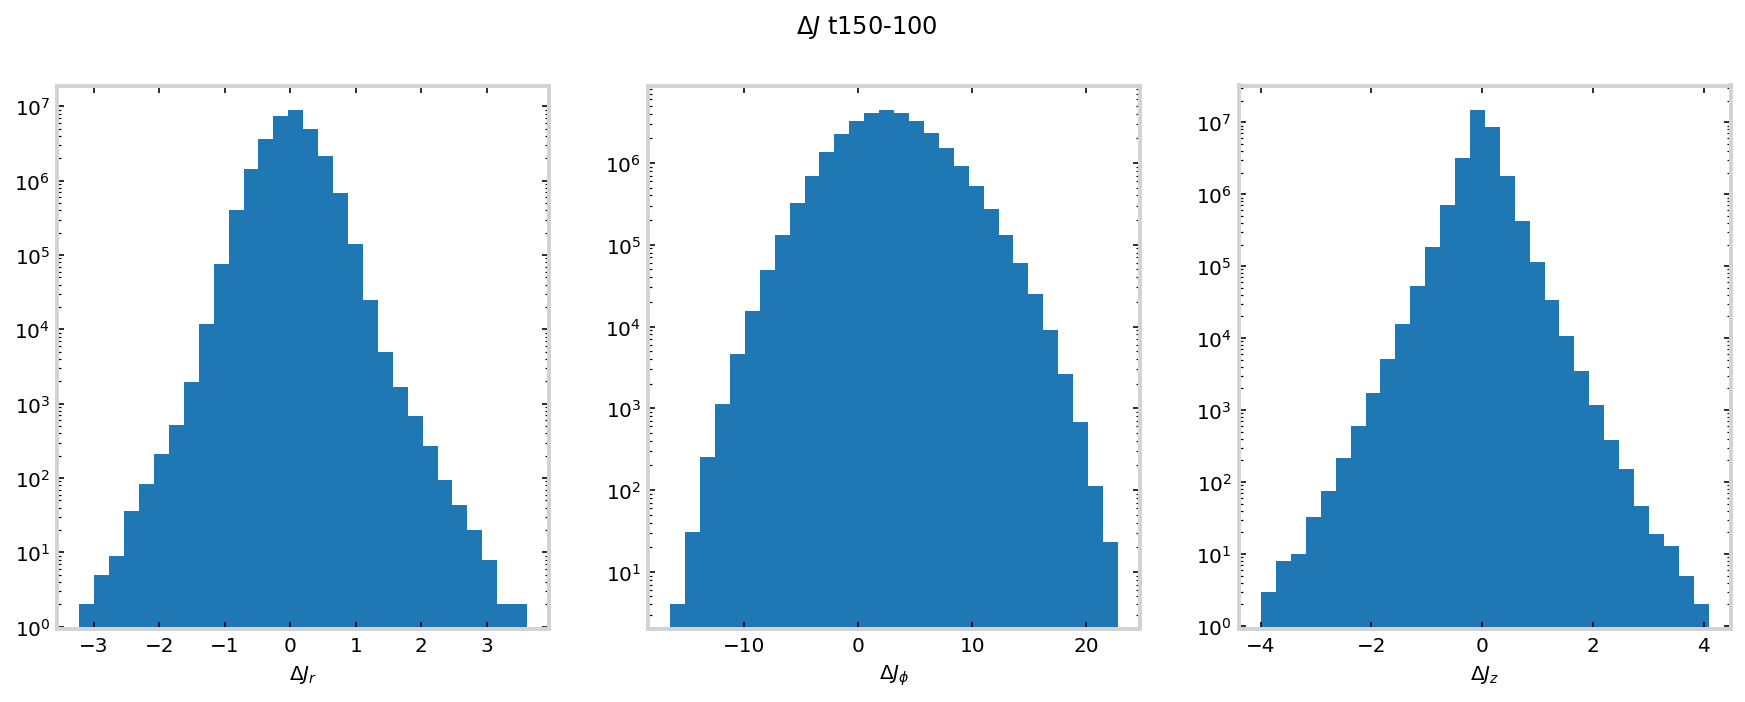

In [16]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist(outer_original150.jr - outer100.jr, bins=30)
axs[0].set_xlabel(r'$\Delta J_r$')
axs[0].set_yscale('log')

axs[1].hist(outer_original150.jphi - outer100.jphi, bins=30)
axs[1].set_xlabel(r'$\Delta J_\phi$')
axs[1].set_yscale('log')

axs[2].hist(outer_original150.jz - outer100.jz, bins=30)
axs[2].set_xlabel(r'$\Delta J_z$')
axs[2].set_yscale('log')
plt.suptitle(r'$\Delta J$ t150-100')
plt.show()

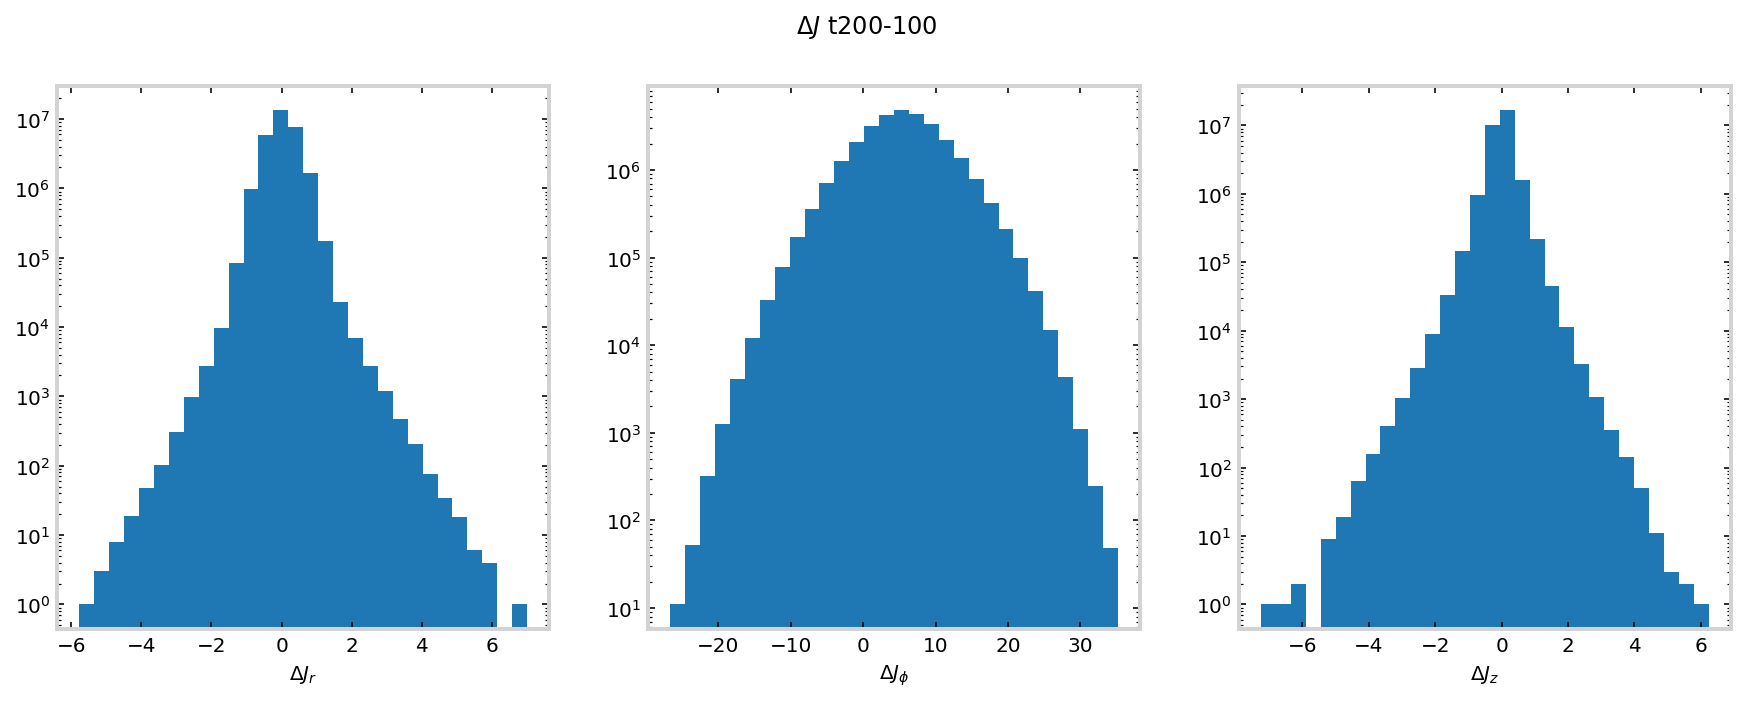

In [17]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist(outer_original200.jr - outer100.jr, bins=30)
axs[0].set_xlabel(r'$\Delta J_r$')
axs[0].set_yscale('log')

axs[1].hist(outer_original200.jphi - outer100.jphi, bins=30)
axs[1].set_xlabel(r'$\Delta J_\phi$')
axs[1].set_yscale('log')

axs[2].hist(outer_original200.jz - outer100.jz, bins=30)
axs[2].set_xlabel(r'$\Delta J_z$')
axs[2].set_yscale('log')
plt.suptitle(r'$\Delta J$ t200-100')
plt.show()

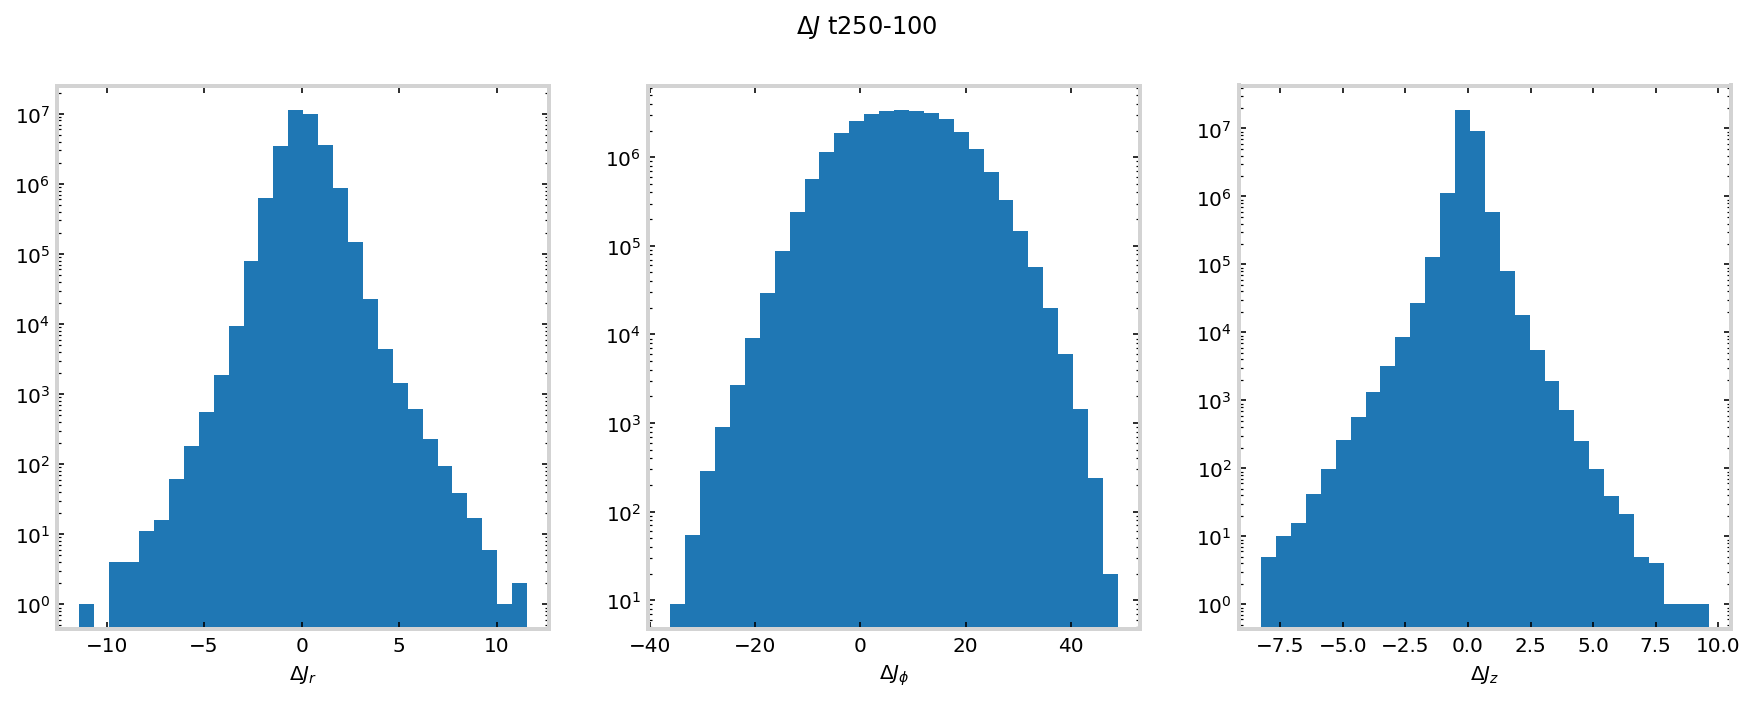

In [18]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist(outer_original250.jr - outer100.jr, bins=30)
axs[0].set_xlabel(r'$\Delta J_r$')
axs[0].set_yscale('log')

axs[1].hist(outer_original250.jphi - outer100.jphi, bins=30)
axs[1].set_xlabel(r'$\Delta J_\phi$')
axs[1].set_yscale('log')

axs[2].hist(outer_original250.jz - outer100.jz, bins=30)
axs[2].set_xlabel(r'$\Delta J_z$')
axs[2].set_yscale('log')
plt.suptitle(r'$\Delta J$ t250-100')
plt.show()

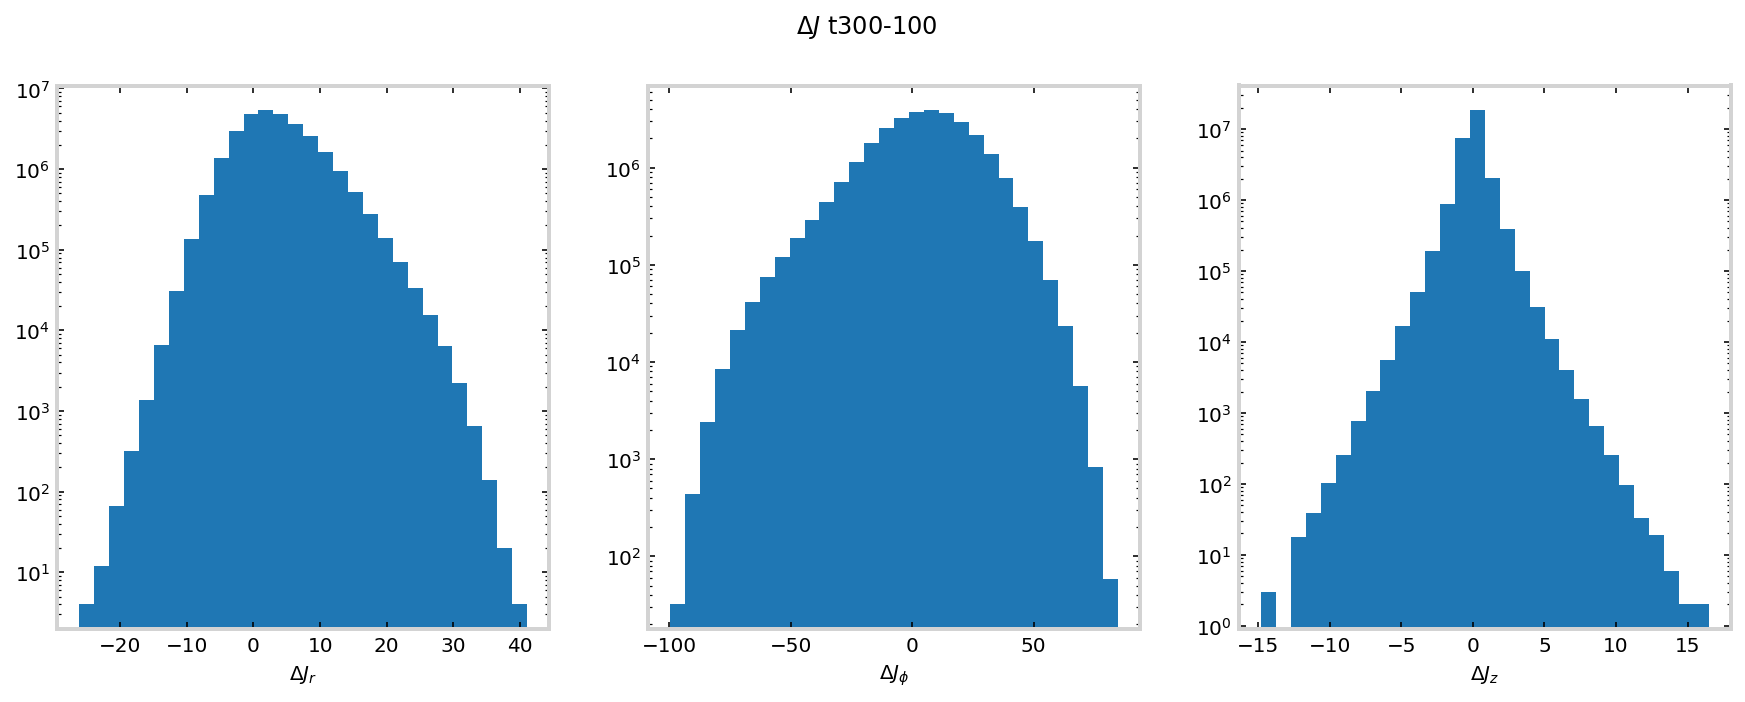

In [19]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist(outer_original300.jr - outer100.jr, bins=30)
axs[0].set_xlabel(r'$\Delta J_r$')
axs[0].set_yscale('log')

axs[1].hist(outer_original300.jphi - outer100.jphi, bins=30)
axs[1].set_xlabel(r'$\Delta J_\phi$')
axs[1].set_yscale('log')

axs[2].hist(outer_original300.jz - outer100.jz, bins=30)
axs[2].set_xlabel(r'$\Delta J_z$')
axs[2].set_yscale('log')
plt.suptitle(r'$\Delta J$ t300-100')
plt.show()

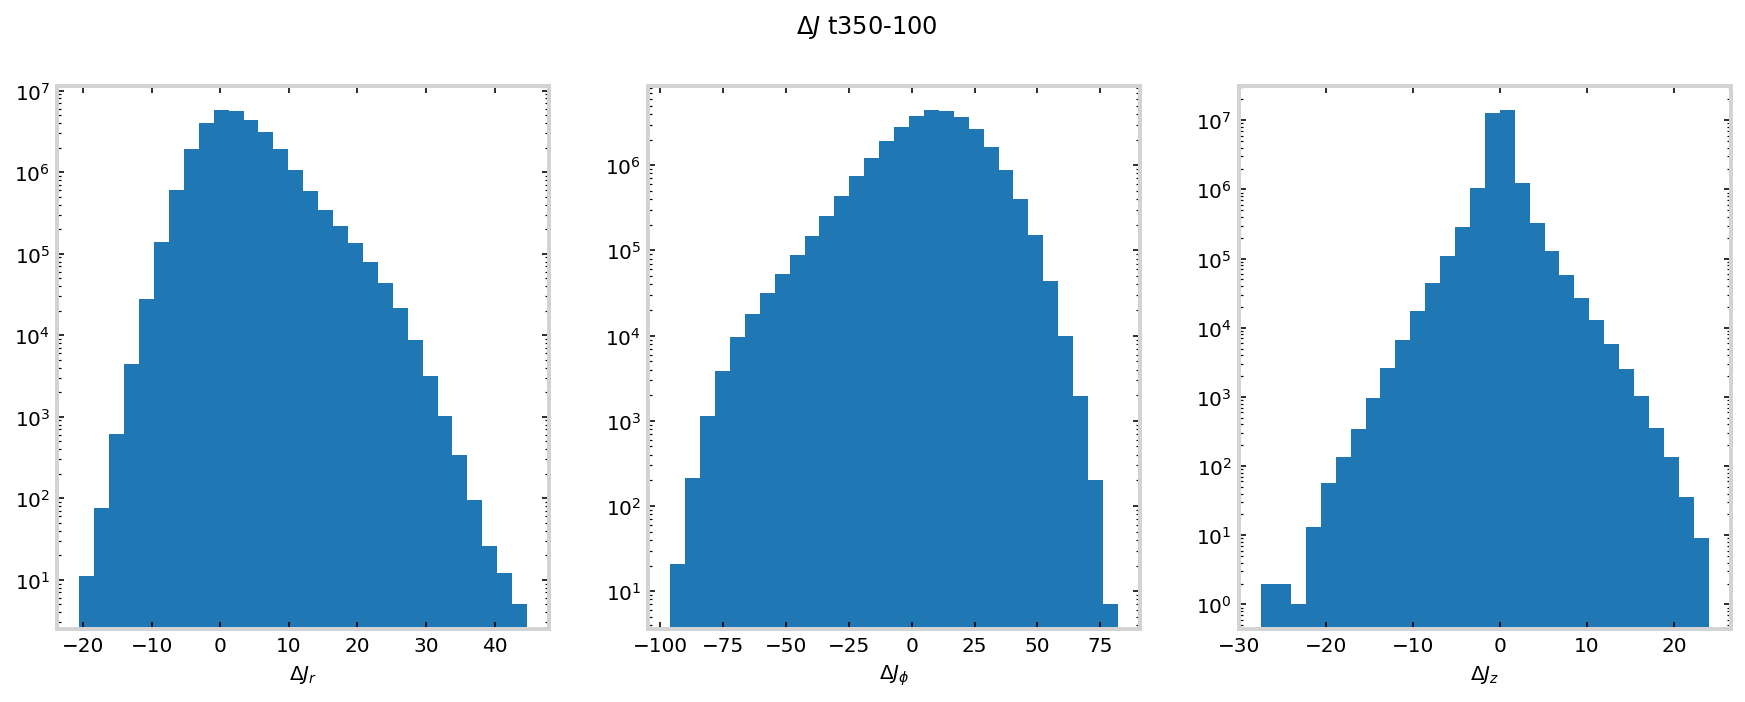

In [20]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist(outer_original350.jr - outer100.jr, bins=30)
axs[0].set_xlabel(r'$\Delta J_r$')
axs[0].set_yscale('log')

axs[1].hist(outer_original350.jphi - outer100.jphi, bins=30)
axs[1].set_xlabel(r'$\Delta J_\phi$')
axs[1].set_yscale('log')

axs[2].hist(outer_original350.jz - outer100.jz, bins=30)
axs[2].set_xlabel(r'$\Delta J_z$')
axs[2].set_yscale('log')
plt.suptitle(r'$\Delta J$ t350-100')
plt.show()

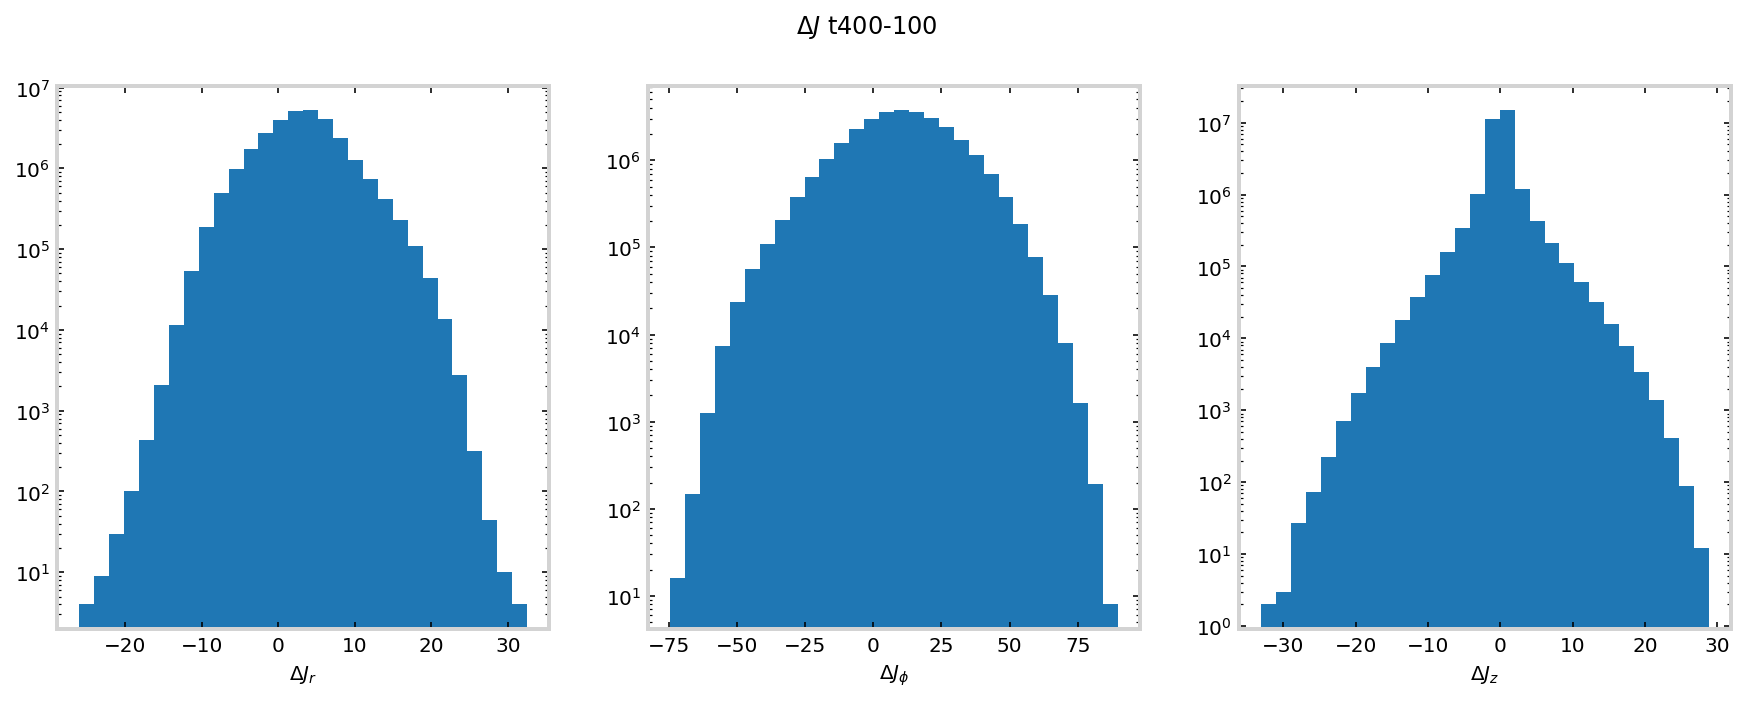

In [21]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist(outer_original400.jr - outer100.jr, bins=30)
axs[0].set_xlabel(r'$\Delta J_r$')
axs[0].set_yscale('log')

axs[1].hist(outer_original400.jphi - outer100.jphi, bins=30)
axs[1].set_xlabel(r'$\Delta J_\phi$')
axs[1].set_yscale('log')

axs[2].hist(outer_original400.jz - outer100.jz, bins=30)
axs[2].set_xlabel(r'$\Delta J_z$')
axs[2].set_yscale('log')
plt.suptitle(r'$\Delta J$ t400-100')
plt.show()

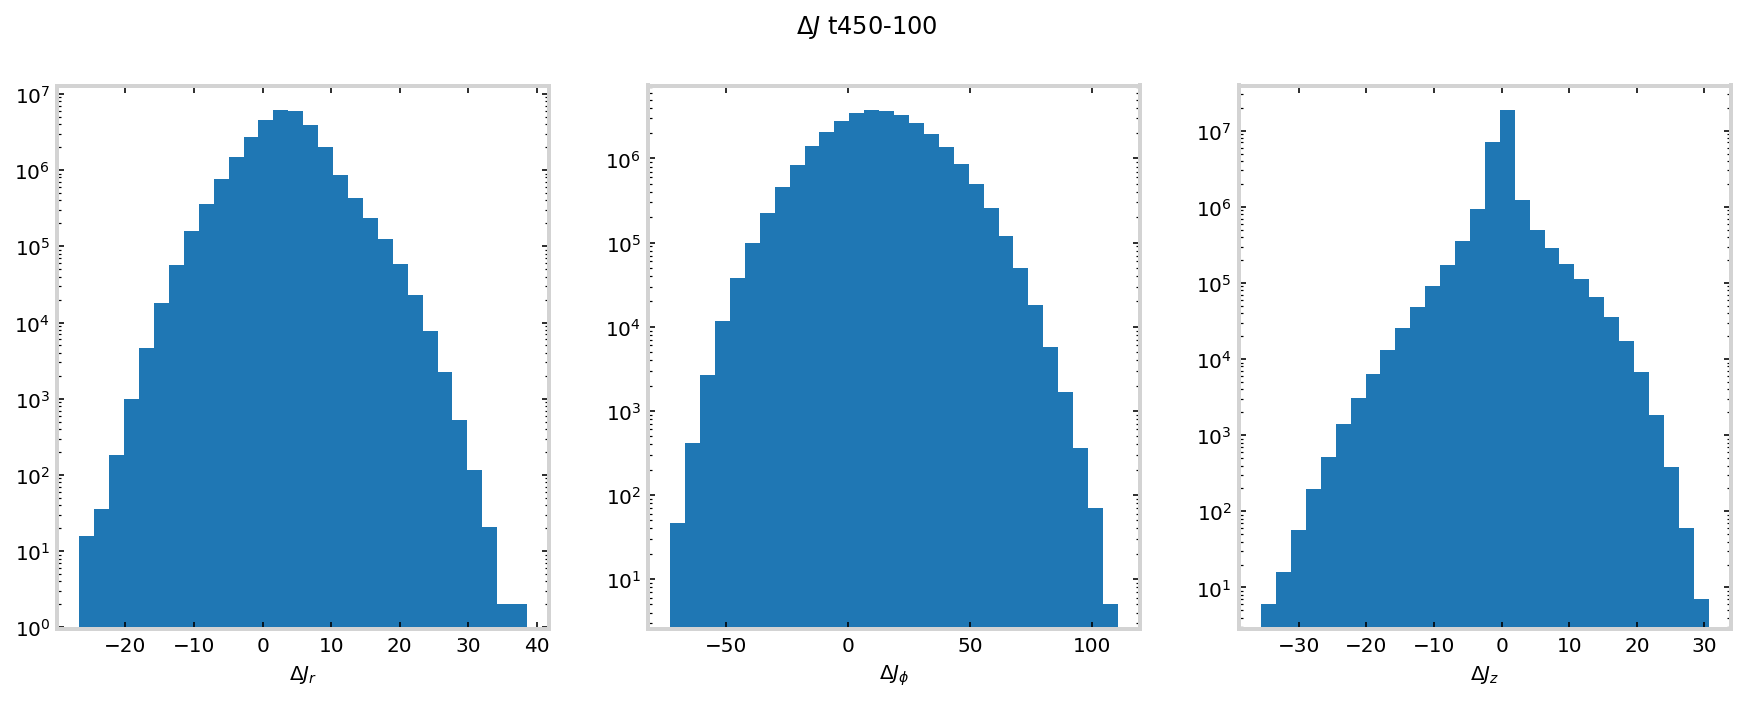

In [22]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist(outer_original450.jr - outer100.jr, bins=30)
axs[0].set_xlabel(r'$\Delta J_r$')
axs[0].set_yscale('log')

axs[1].hist(outer_original450.jphi - outer100.jphi, bins=30)
axs[1].set_xlabel(r'$\Delta J_\phi$')
axs[1].set_yscale('log')

axs[2].hist(outer_original450.jz - outer100.jz, bins=30)
axs[2].set_xlabel(r'$\Delta J_z$')
axs[2].set_yscale('log')
plt.suptitle(r'$\Delta J$ t450-100')
plt.show()

## Let's Make 2D Histograms

Text(0.5, 0, '$\\Delta J_z$')

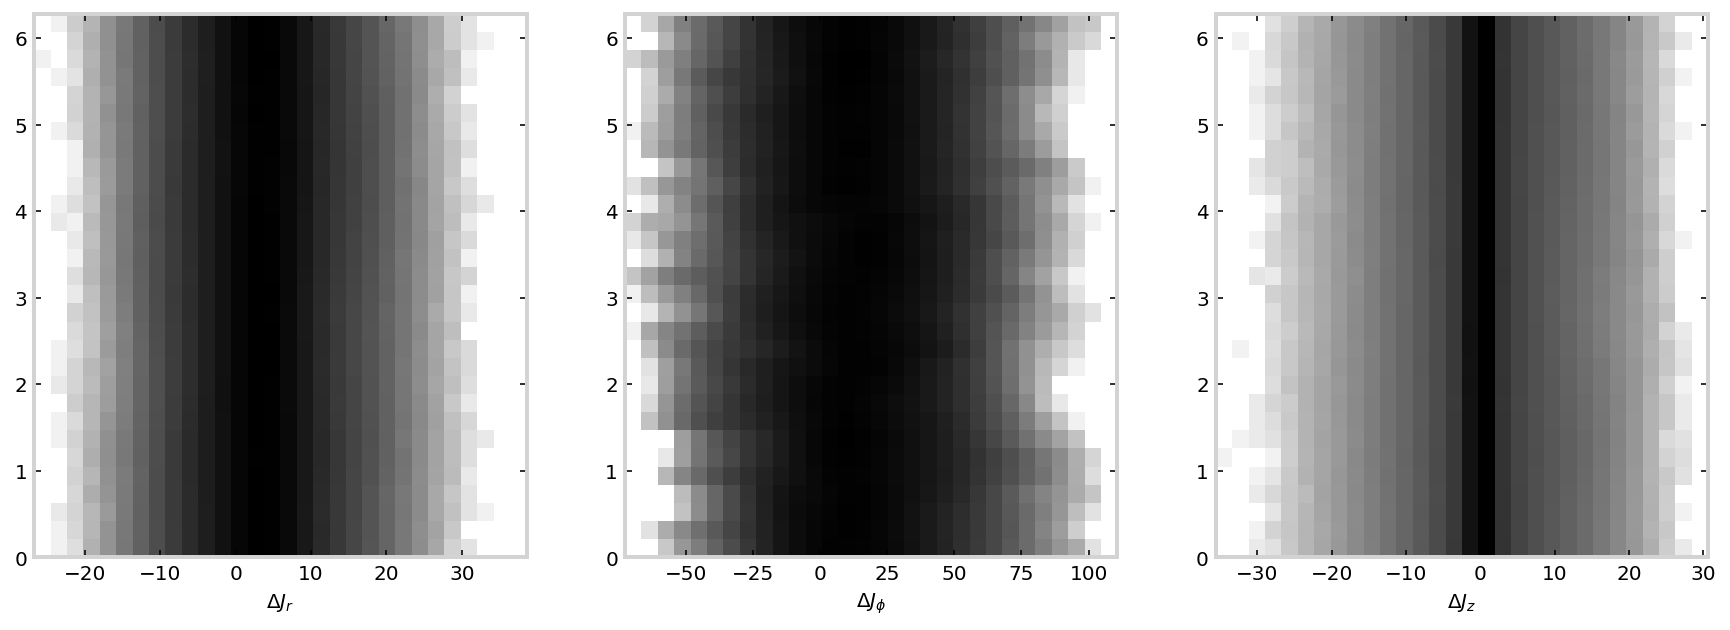

In [23]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist2d(outer_original450.jr - outer100.jr, outer100.theta_phi, bins=30,
             norm=mpl.colors.LogNorm(), cmap='gray_r')
axs[0].set_xlabel(r'$\Delta J_r$')

axs[1].hist2d(outer_original450.jphi - outer100.jphi, outer100.theta_phi, bins=30,
             norm=mpl.colors.LogNorm(), cmap='gray_r')
axs[1].set_xlabel(r'$\Delta J_\phi$')

axs[2].hist2d(outer_original450.jz - outer100.jz, outer100.theta_phi, bins=30,
             norm=mpl.colors.LogNorm(), cmap='gray_r')
axs[2].set_xlabel(r'$\Delta J_z$')

I want to make eye plots colored by $\Delta J$

In [24]:
thetas = np.arange(0, 2*np.pi, 32)
delta_jrs = np.arange(-30,30,50)
delta_jphis = np.arange(-100,100,50)
delta_jzs = np.arange(-30,30,50)

T, R = np.meshgrid(thetas, delta_jrs)
T, PHI = np.meshgrid(thetas, delta_jphis)
T, Z = np.meshgrid(thetas, delta_jzs)

TypeError: pcolormesh() takes 1 or 3 positional arguments but 2 were given

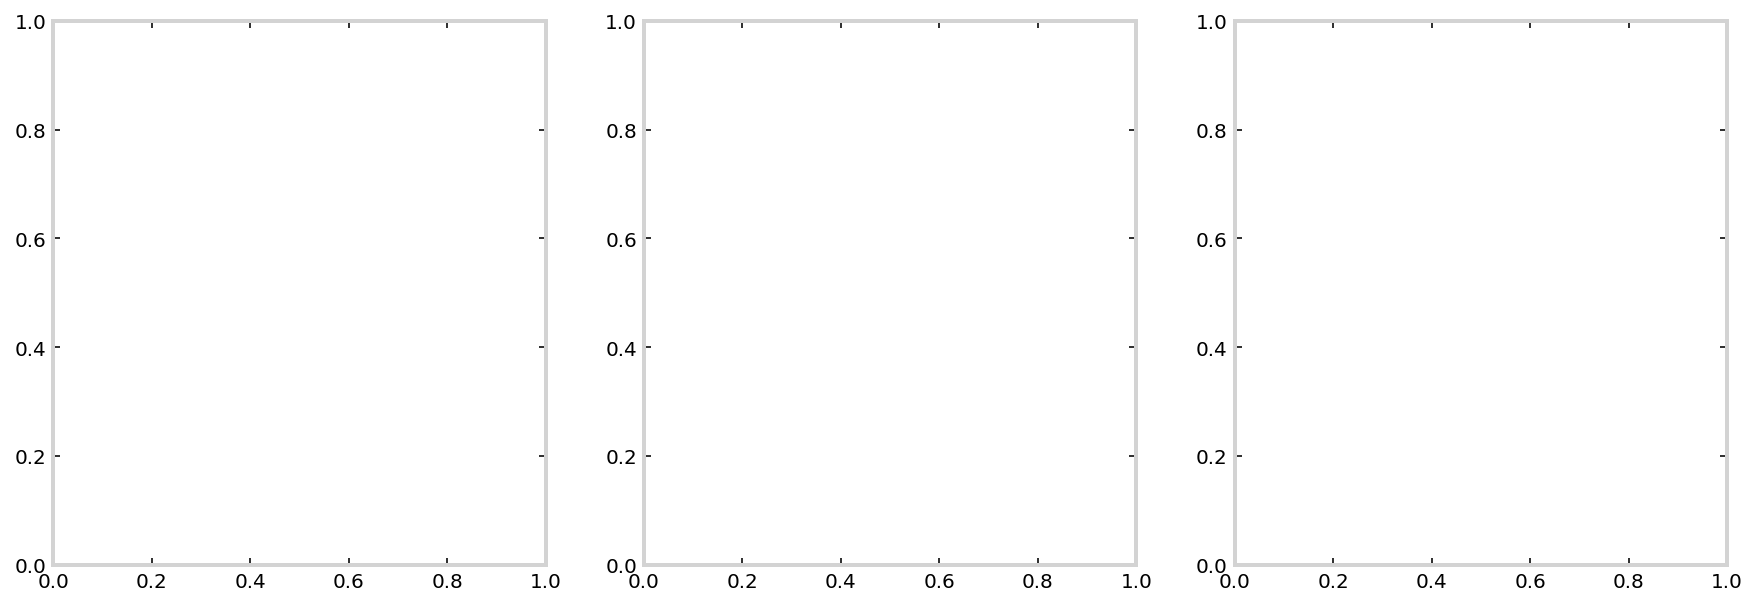

In [26]:
fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].pcolormesh(T, R, bins=30,
             norm=mpl.colors.LogNorm(), cmap='gray_r')
axs[0].set_xlabel(r'$\Delta J_r$')

axs[1].pcolormesh(T, PHI, bins=30,
             norm=mpl.colors.LogNorm(), cmap='gray_r')
axs[1].set_xlabel(r'$\Delta J_\phi$')

axs[2].pcolormesh(T, Z, bins=30,
             norm=mpl.colors.LogNorm(), cmap='gray_r')
axs[2].set_xlabel(r'$\Delta J_z$')

## Looking at Populations in Annuli At Different Times

Split up the outer disk into smaller annuli. Also focus on $J_r$ from now on.

In [ ]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist(outer100.jr[(outer100.jphi < 2100)] , bins=30)
axs[0].set_xlabel(r'$J_r$')
axs[0].set_yscale('log')

axs[1].hist(outer100.jr[(outer100.jphi > 2450) & (outer100.jphi < 2550)], bins=30)
axs[1].set_xlabel(r'$J_r$')
axs[1].set_yscale('log')

axs[2].hist(outer100.jr[(outer100.jphi > 2900)], bins=30)
axs[2].set_xlabel(r'$J_r$')
axs[2].set_yscale('log')
plt.suptitle(r'$J_r$ t100')
plt.show()

In [ ]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist(outer200.jr[(outer200.jphi < 2100)] , bins=30)
axs[0].set_xlabel(r'$J_r$')
axs[0].set_yscale('log')

axs[1].hist(outer200.jr[(outer200.jphi > 2450) & (outer200.jphi < 2550)], bins=30)
axs[1].set_xlabel(r'$J_r$')
axs[1].set_yscale('log')

axs[2].hist(outer200.jr[(outer200.jphi > 2900)], bins=30)
axs[2].set_xlabel(r'$J_r$')
axs[2].set_yscale('log')
plt.suptitle(r'$J_r$ t200')
plt.show()

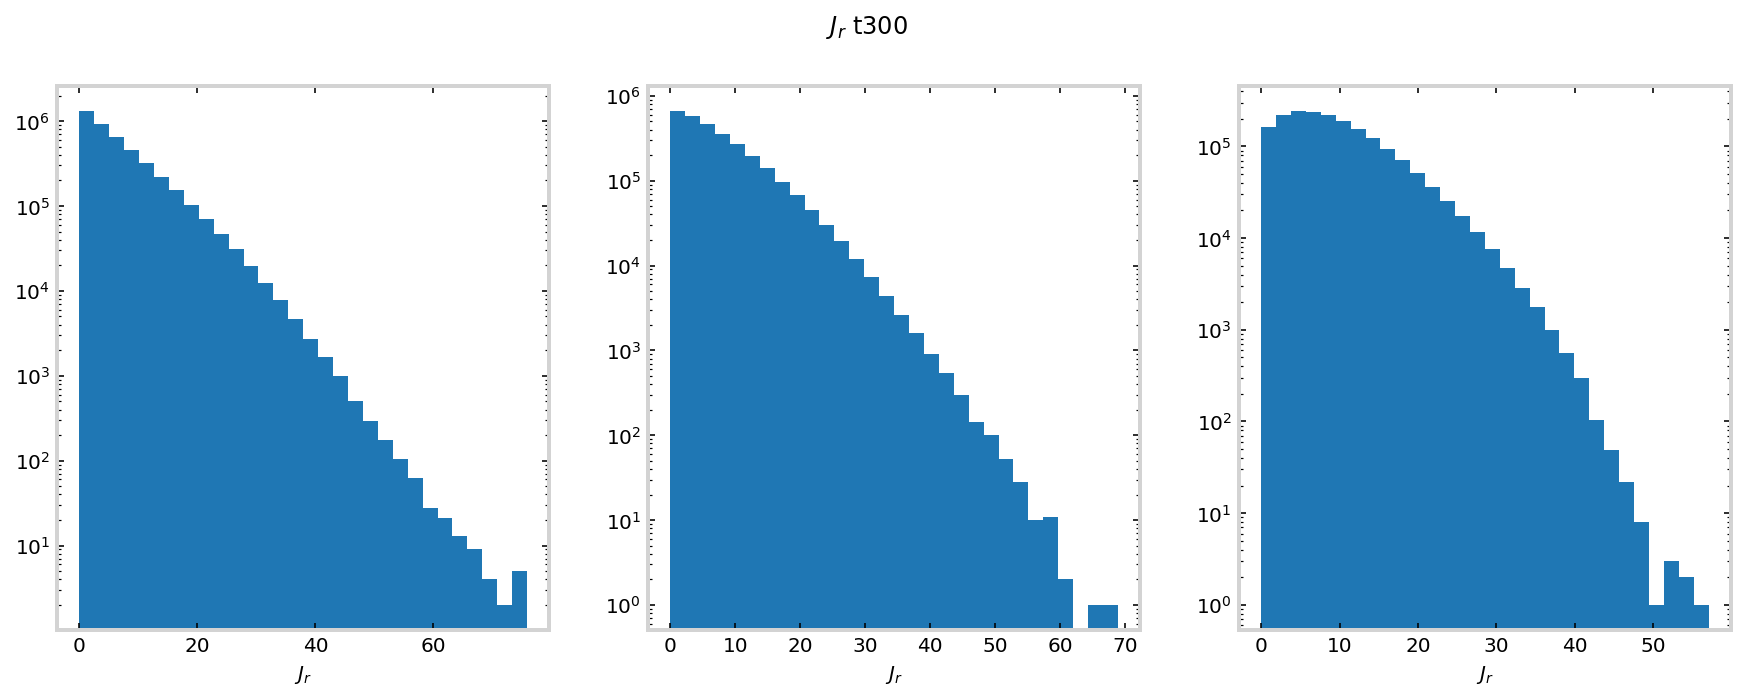

In [27]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist(outer300.jr[(outer300.jphi < 2100)] , bins=30)
axs[0].set_xlabel(r'$J_r$')
axs[0].set_yscale('log')

axs[1].hist(outer300.jr[(outer300.jphi > 2450) & (outer300.jphi < 2550)], bins=30)
axs[1].set_xlabel(r'$J_r$')
axs[1].set_yscale('log')

axs[2].hist(outer300.jr[(outer300.jphi > 2900)], bins=30)
axs[2].set_xlabel(r'$J_r$')
axs[2].set_yscale('log')
plt.suptitle(r'$J_r$ t300')
plt.show()

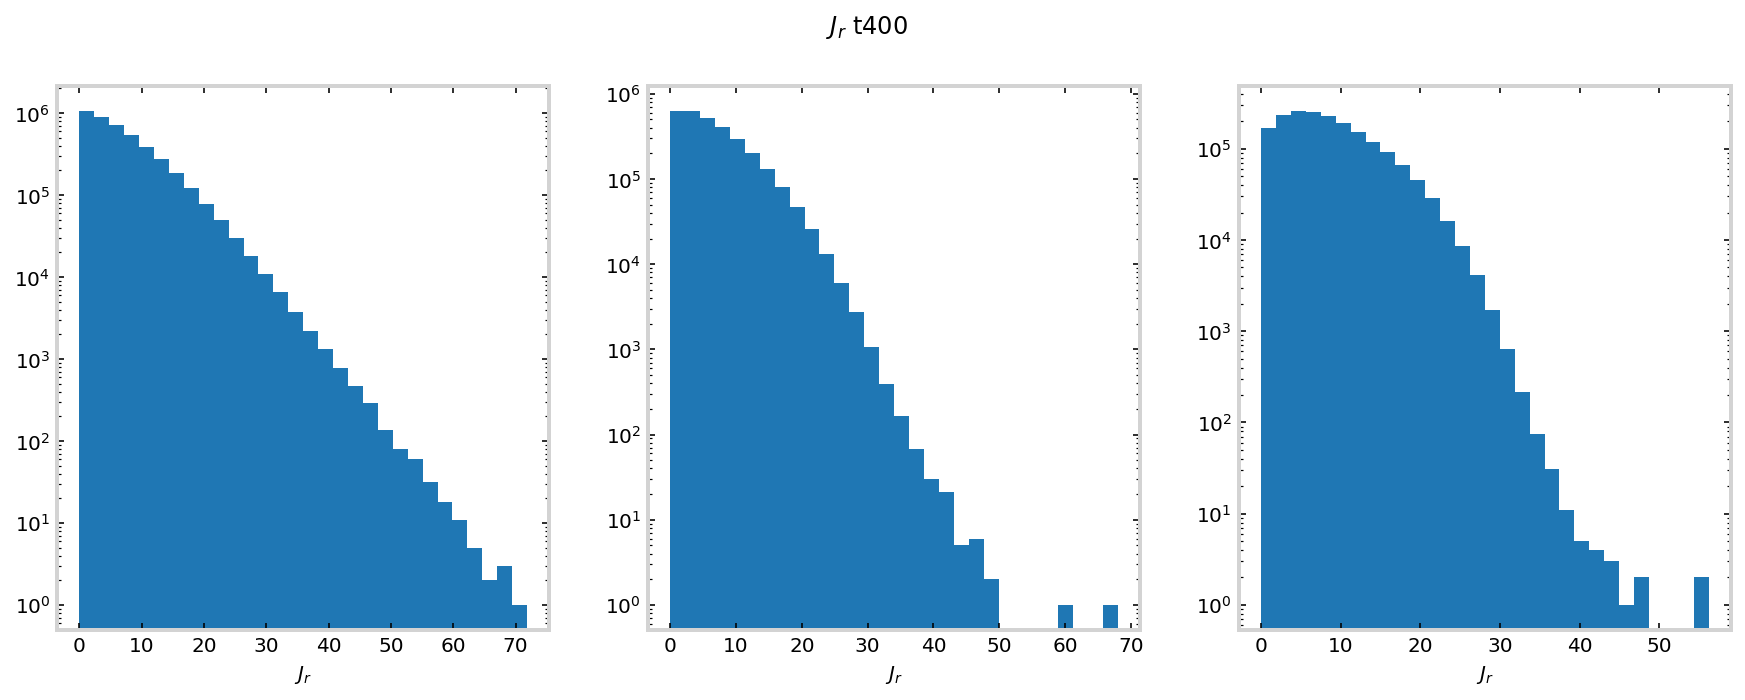

In [28]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist(outer400.jr[(outer400.jphi < 2100)] , bins=30)
axs[0].set_xlabel(r'$J_r$')
axs[0].set_yscale('log')

axs[1].hist(outer400.jr[(outer400.jphi > 2450) & (outer400.jphi < 2550)], bins=30)
axs[1].set_xlabel(r'$J_r$')
axs[1].set_yscale('log')

axs[2].hist(outer400.jr[(outer400.jphi > 2900)], bins=30)
axs[2].set_xlabel(r'$J_r$')
axs[2].set_yscale('log')
plt.suptitle(r'$J_r$ t400')
plt.show()

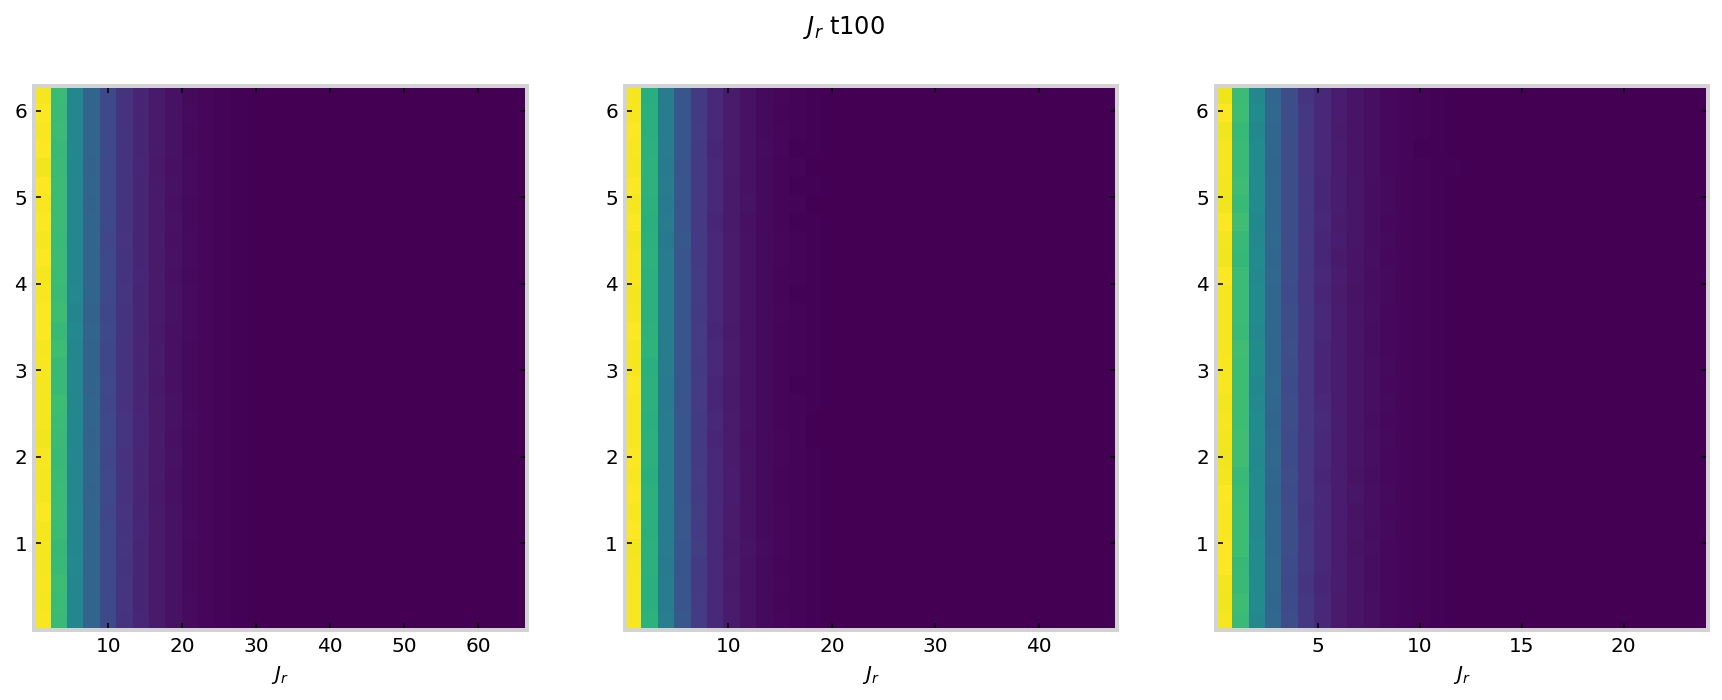

In [29]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist2d(outer100.jr[(outer100.jphi < 2100)], outer100.theta_phi[(outer100.jphi < 2100)], 
              bins=30)
axs[0].set_xlabel(r'$J_r$')

axs[1].hist2d(outer100.jr[(outer100.jphi > 2450) & (outer100.jphi < 2550)], 
              outer100.theta_phi[(outer100.jphi > 2450) & (outer100.jphi < 2550)], bins=30)
axs[1].set_xlabel(r'$J_r$')

axs[2].hist2d(outer100.jr[(outer100.jphi > 2900)], outer100.theta_phi[(outer100.jphi > 2900)], bins=30)
axs[2].set_xlabel(r'$J_r$')
plt.suptitle(r'$J_r$ t100')
plt.show()

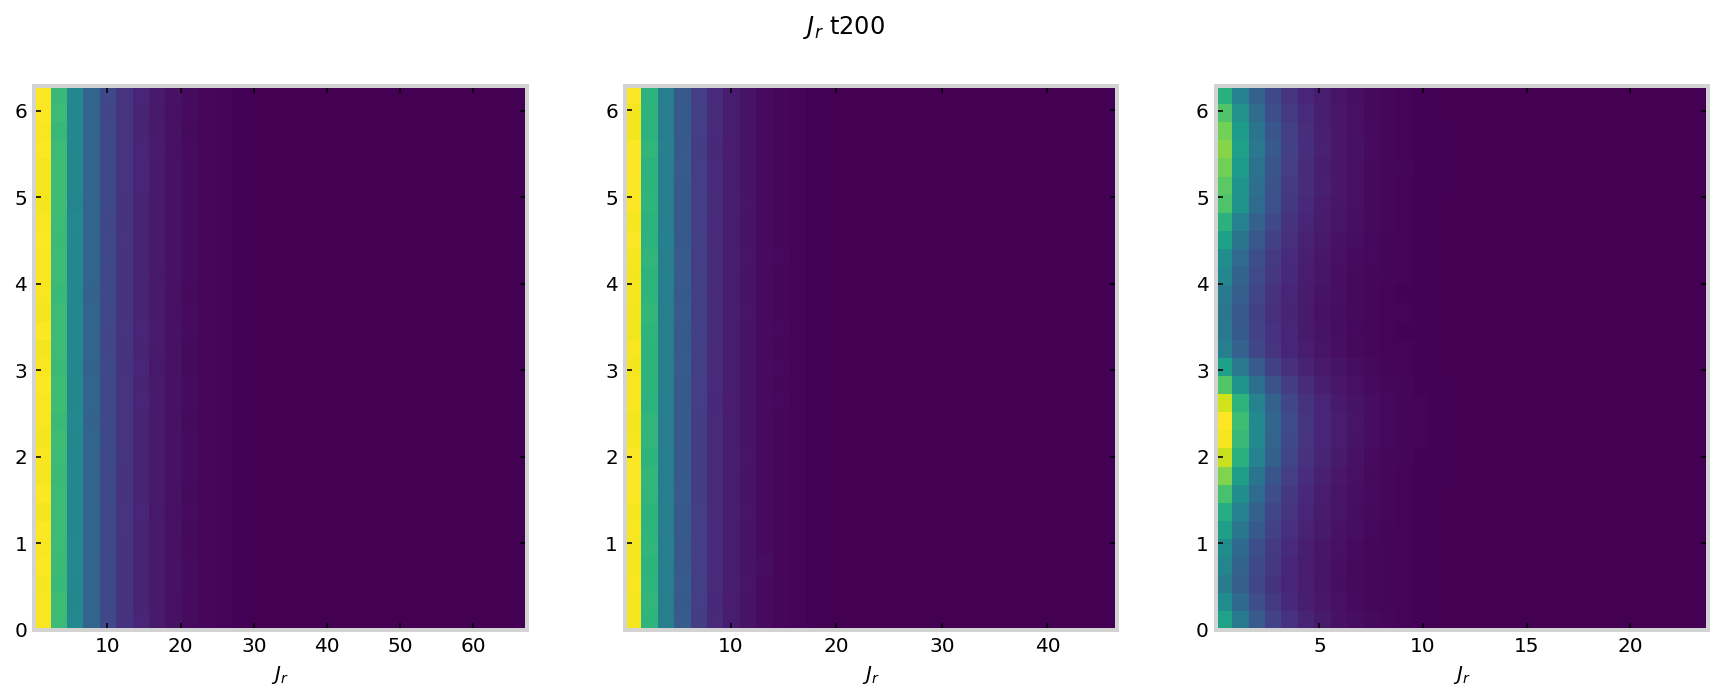

In [30]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist2d(outer200.jr[(outer200.jphi < 2100)], outer200.theta_phi[(outer200.jphi < 2100)], 
              bins=30)
axs[0].set_xlabel(r'$J_r$')

axs[1].hist2d(outer200.jr[(outer200.jphi > 2450) & (outer200.jphi < 2550)], 
              outer200.theta_phi[(outer200.jphi > 2450) & (outer200.jphi < 2550)], bins=30)
axs[1].set_xlabel(r'$J_r$')

axs[2].hist2d(outer200.jr[(outer200.jphi > 2900)], outer200.theta_phi[(outer200.jphi > 2900)], bins=30)
axs[2].set_xlabel(r'$J_r$')
plt.suptitle(r'$J_r$ t200')
plt.show()

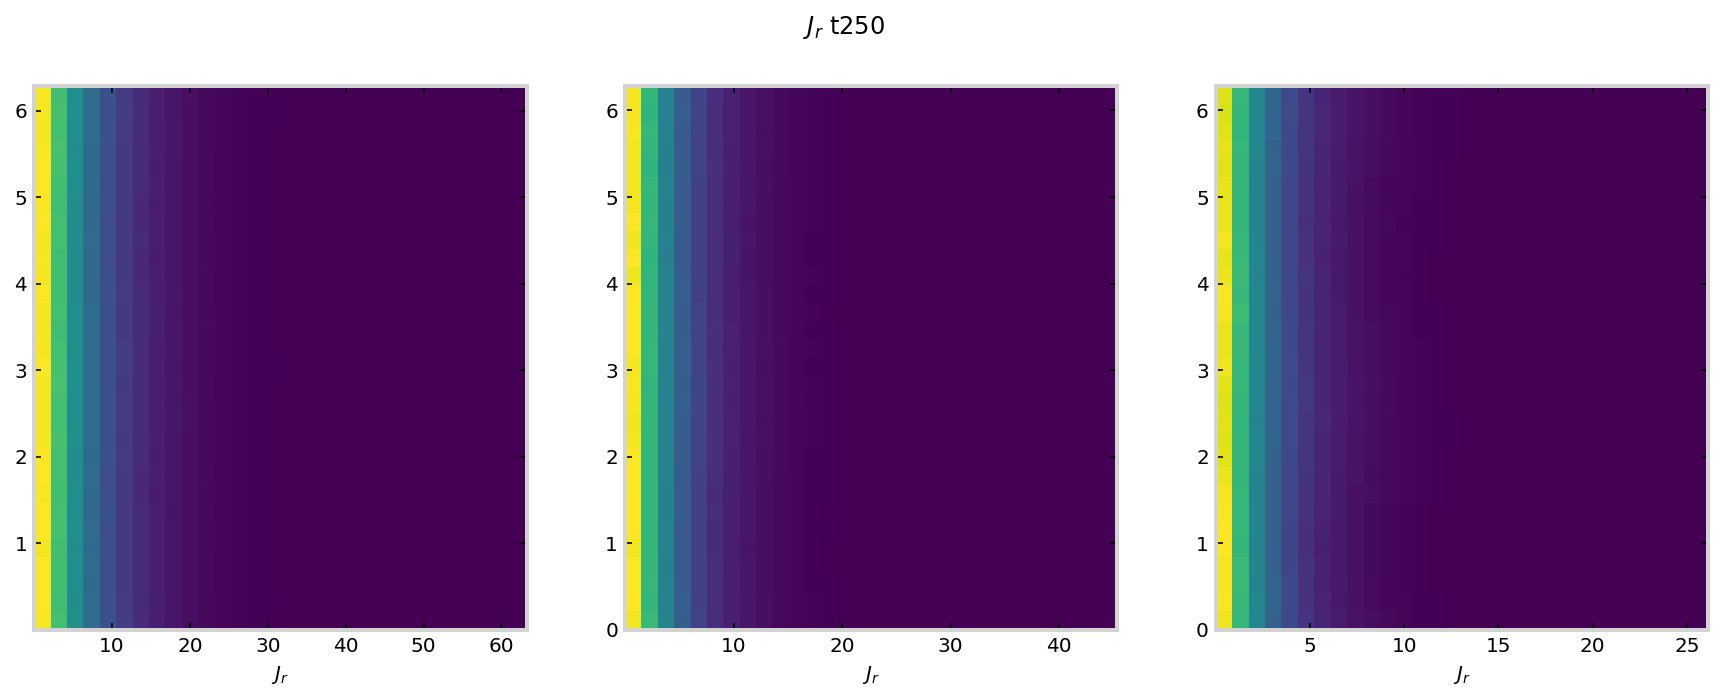

In [31]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist2d(outer250.jr[(outer250.jphi < 2100)], outer250.theta_phi[(outer250.jphi < 2100)], 
              bins=30)
axs[0].set_xlabel(r'$J_r$')

axs[1].hist2d(outer250.jr[(outer250.jphi > 2450) & (outer250.jphi < 2550)], 
              outer250.theta_phi[(outer250.jphi > 2450) & (outer250.jphi < 2550)], bins=30)
axs[1].set_xlabel(r'$J_r$')

axs[2].hist2d(outer250.jr[(outer250.jphi > 2900)], outer250.theta_phi[(outer250.jphi > 2900)], bins=30)
axs[2].set_xlabel(r'$J_r$')
plt.suptitle(r'$J_r$ t250')
plt.show()

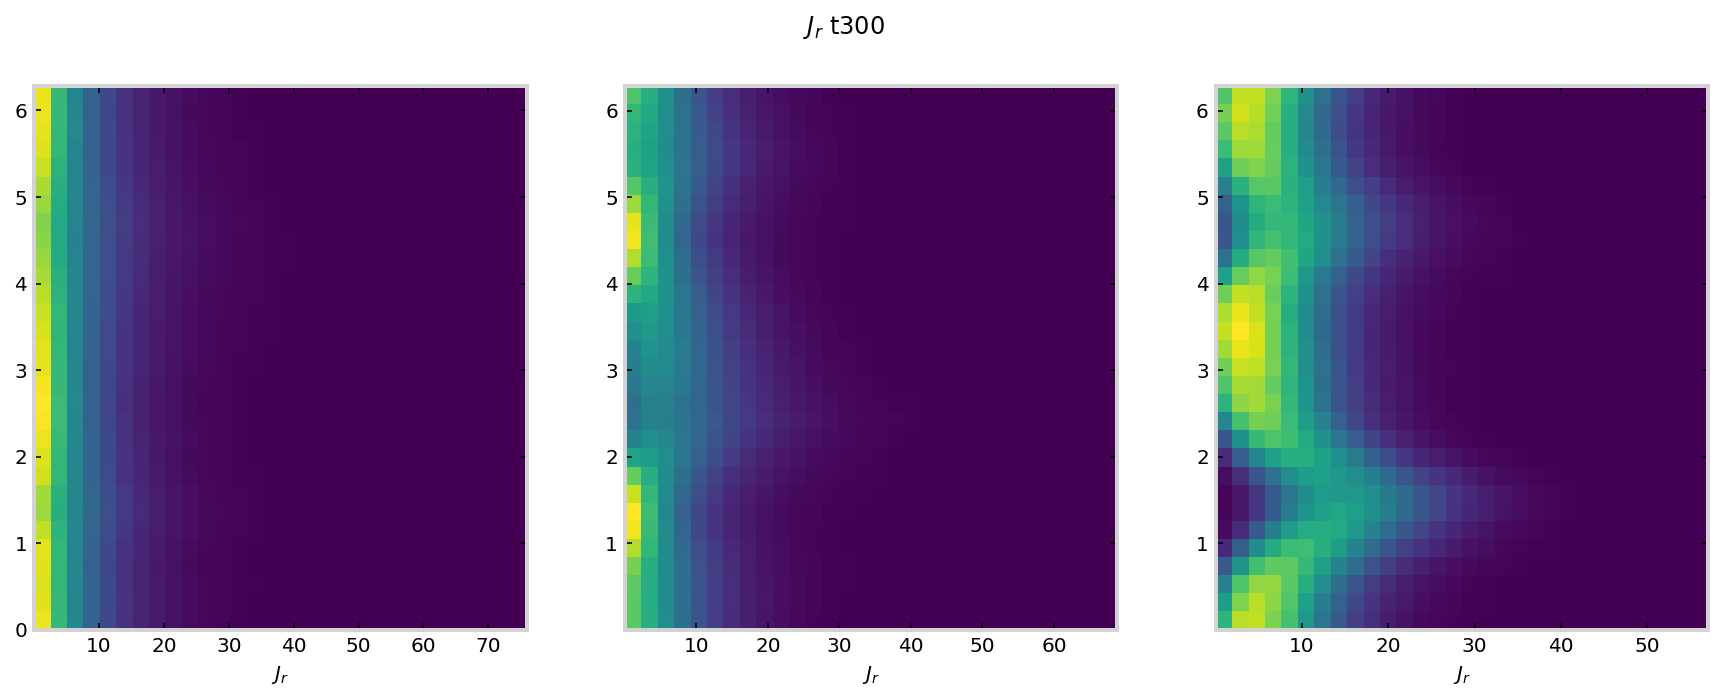

In [32]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist2d(outer300.jr[(outer300.jphi < 2100)], outer300.theta_phi[(outer300.jphi < 2100)], 
              bins=30)
axs[0].set_xlabel(r'$J_r$')

axs[1].hist2d(outer300.jr[(outer300.jphi > 2450) & (outer300.jphi < 2550)], 
              outer300.theta_phi[(outer300.jphi > 2450) & (outer300.jphi < 2550)], bins=30)
axs[1].set_xlabel(r'$J_r$')

axs[2].hist2d(outer300.jr[(outer300.jphi > 2900)], outer300.theta_phi[(outer300.jphi > 2900)], bins=30)
axs[2].set_xlabel(r'$J_r$')
plt.suptitle(r'$J_r$ t300')
plt.show()

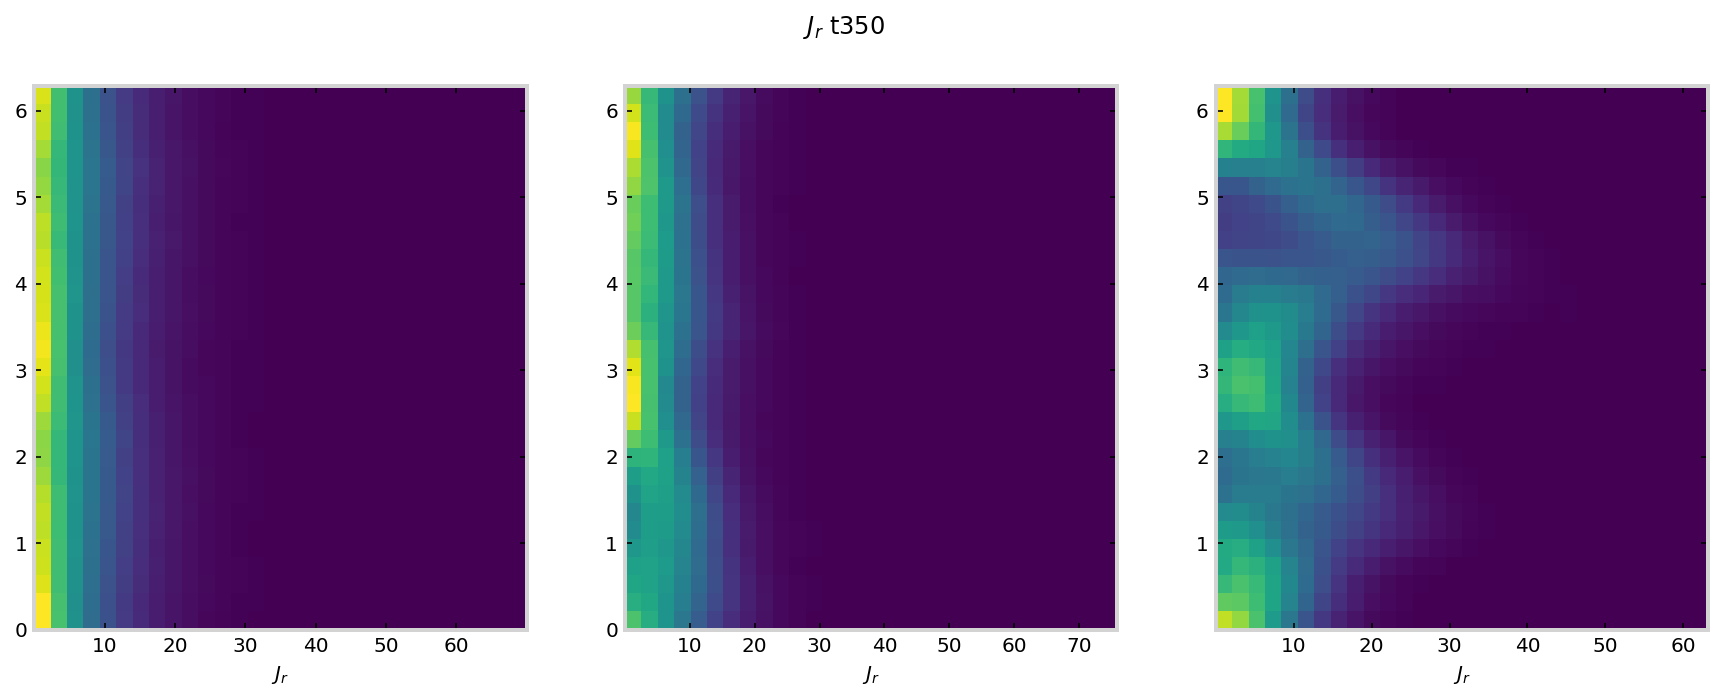

In [33]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist2d(outer350.jr[(outer350.jphi < 2100)], outer350.theta_phi[(outer350.jphi < 2100)], 
              bins=30)
axs[0].set_xlabel(r'$J_r$')

axs[1].hist2d(outer350.jr[(outer350.jphi > 2450) & (outer350.jphi < 2550)], 
              outer350.theta_phi[(outer350.jphi > 2450) & (outer350.jphi < 2550)], bins=30)
axs[1].set_xlabel(r'$J_r$')

axs[2].hist2d(outer350.jr[(outer350.jphi > 2900)], outer350.theta_phi[(outer350.jphi > 2900)], bins=30)
axs[2].set_xlabel(r'$J_r$')
plt.suptitle(r'$J_r$ t350')
plt.show()

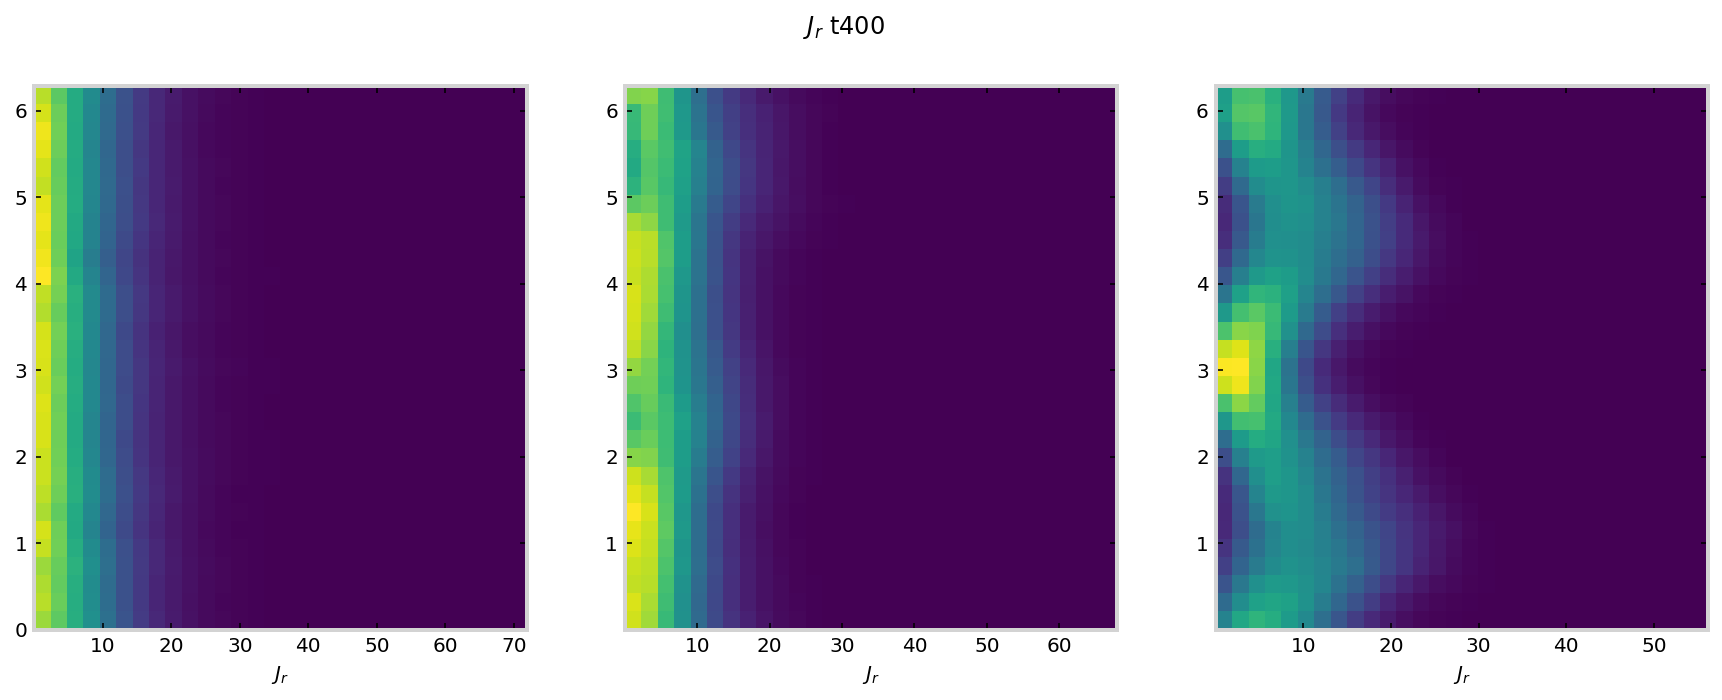

In [34]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist2d(outer400.jr[(outer400.jphi < 2100)], outer400.theta_phi[(outer400.jphi < 2100)], 
              bins=30)
axs[0].set_xlabel(r'$J_r$')

axs[1].hist2d(outer400.jr[(outer400.jphi > 2450) & (outer400.jphi < 2550)], 
              outer400.theta_phi[(outer400.jphi > 2450) & (outer400.jphi < 2550)], bins=30)
axs[1].set_xlabel(r'$J_r$')

axs[2].hist2d(outer400.jr[(outer400.jphi > 2900)], outer400.theta_phi[(outer400.jphi > 2900)], bins=30)
axs[2].set_xlabel(r'$J_r$')
plt.suptitle(r'$J_r$ t400')
plt.show()

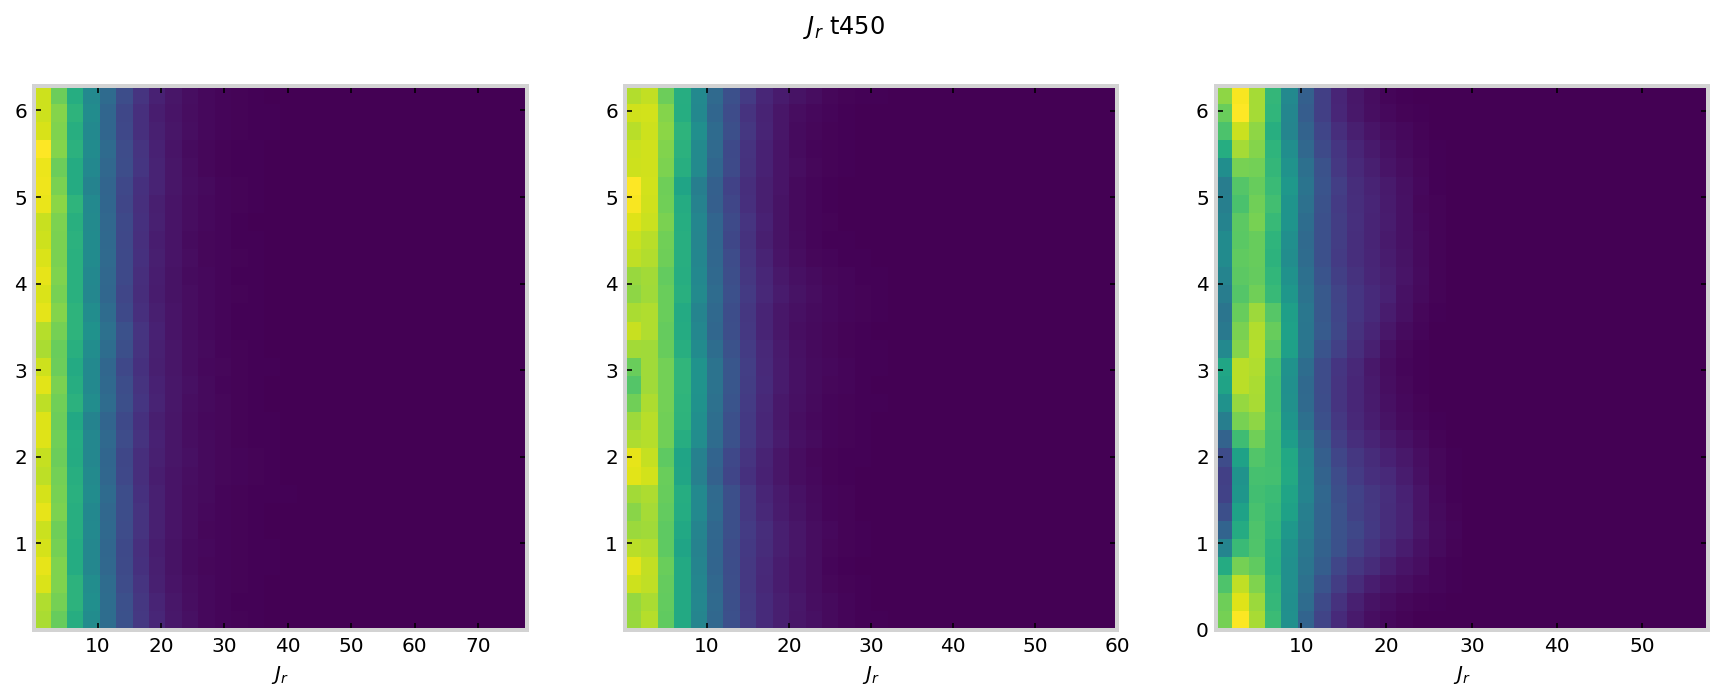

In [35]:
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist2d(outer450.jr[(outer450.jphi < 2100)], outer450.theta_phi[(outer450.jphi < 2100)], 
              bins=30)
axs[0].set_xlabel(r'$J_r$')

axs[1].hist2d(outer450.jr[(outer450.jphi > 2450) & (outer450.jphi < 2550)], 
              outer450.theta_phi[(outer450.jphi > 2450) & (outer450.jphi < 2550)], bins=30)
axs[1].set_xlabel(r'$J_r$')

axs[2].hist2d(outer450.jr[(outer450.jphi > 2900)], outer450.theta_phi[(outer450.jphi > 2900)], bins=30)
axs[2].set_xlabel(r'$J_r$')
plt.suptitle(r'$J_r$ t450')
plt.show()

### With the $\Delta J_r$

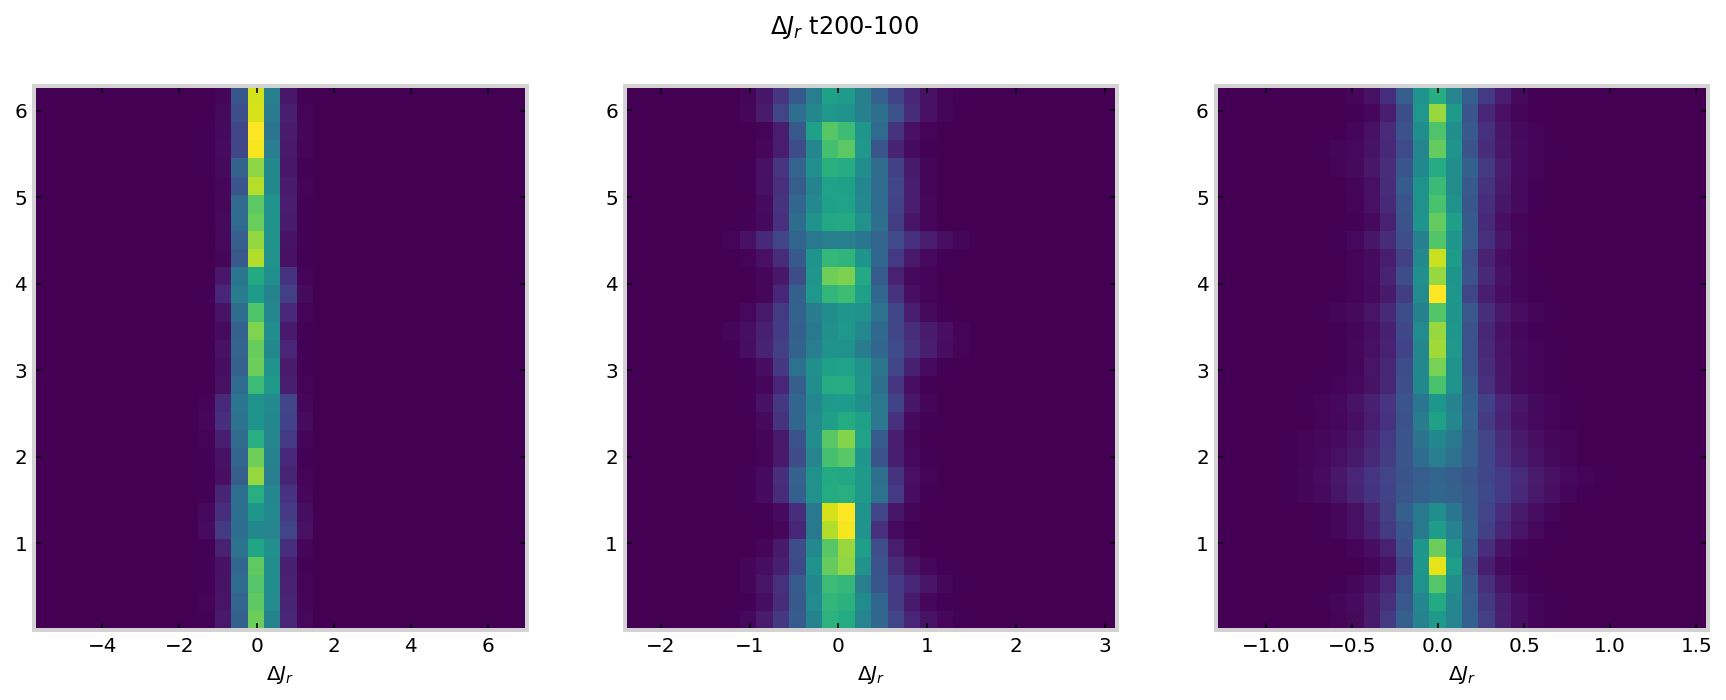

In [36]:
outer_inner = (outer100.jphi < 2100)
outer_middle = (outer100.jphi > 2450) & (outer100.jphi < 2550)
outer_outer = (outer100.jphi > 2900)

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist2d(outer_original200.jr[outer_inner] - outer100.jr[outer_inner], 
              outer100.theta_phi[outer_inner], 
              bins=30)
axs[0].set_xlabel(r'$\Delta J_r$')

axs[1].hist2d(outer_original200.jr[outer_middle] - outer100.jr[outer_middle], 
              outer_original200.theta_phi[outer_middle], bins=30)
axs[1].set_xlabel(r'$\Delta J_r$')

axs[2].hist2d(outer_original200.jr[outer_outer] - outer100.jr[outer_outer], outer100.theta_phi[outer_outer], bins=30)
axs[2].set_xlabel(r'$\Delta J_r$')
plt.suptitle(r'$\Delta J_r$ t200-100')
plt.show()

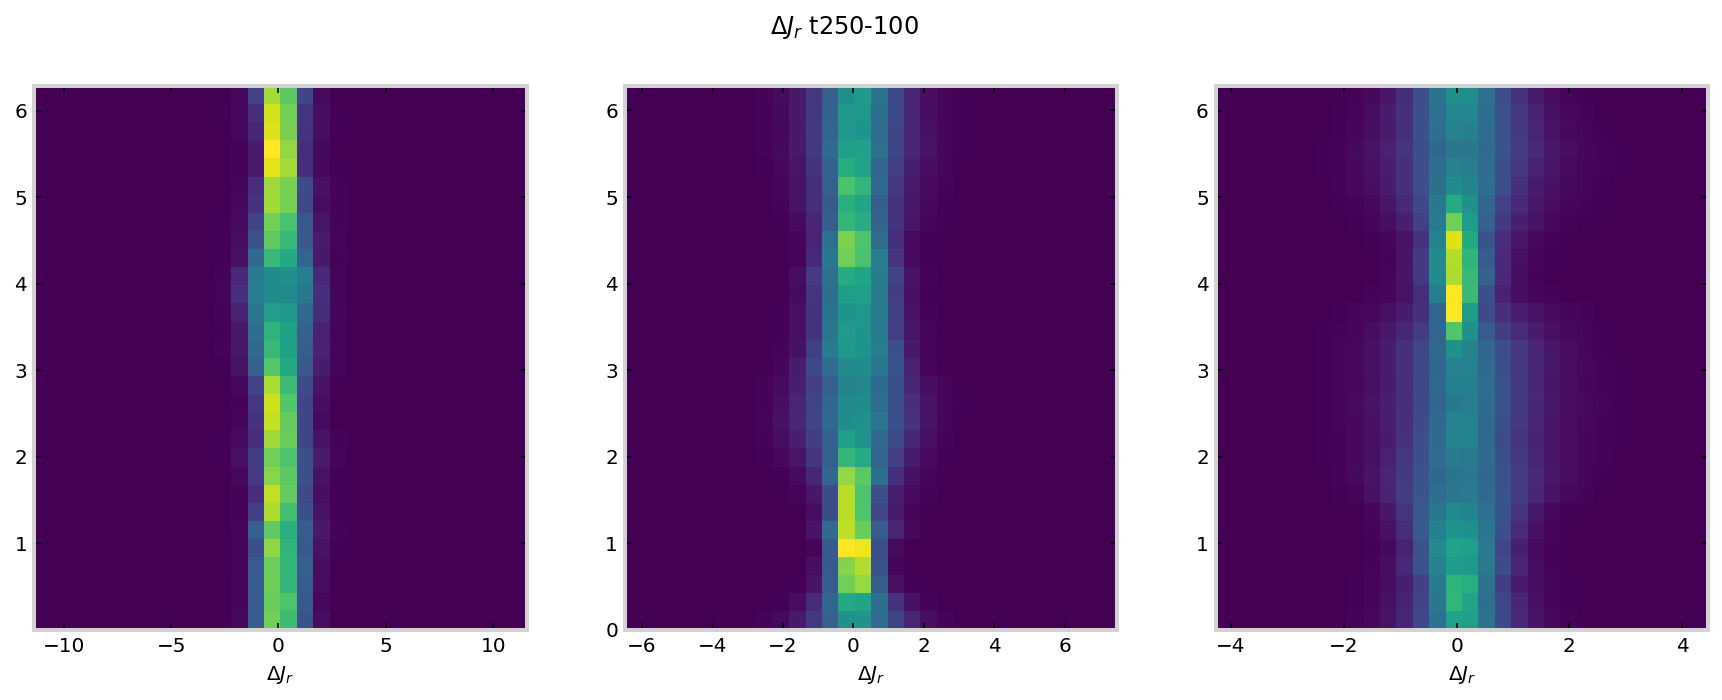

In [37]:
fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist2d(outer_original250.jr[outer_inner] - outer100.jr[outer_inner], 
              outer100.theta_phi[outer_inner], 
              bins=30)
axs[0].set_xlabel(r'$\Delta J_r$')

axs[1].hist2d(outer_original250.jr[outer_middle] - outer100.jr[outer_middle], 
              outer_original250.theta_phi[outer_middle], bins=30)
axs[1].set_xlabel(r'$\Delta J_r$')

axs[2].hist2d(outer_original250.jr[outer_outer] - outer100.jr[outer_outer], outer100.theta_phi[outer_outer], bins=30)
axs[2].set_xlabel(r'$\Delta J_r$')
plt.suptitle(r'$\Delta J_r$ t250-100')
plt.show()

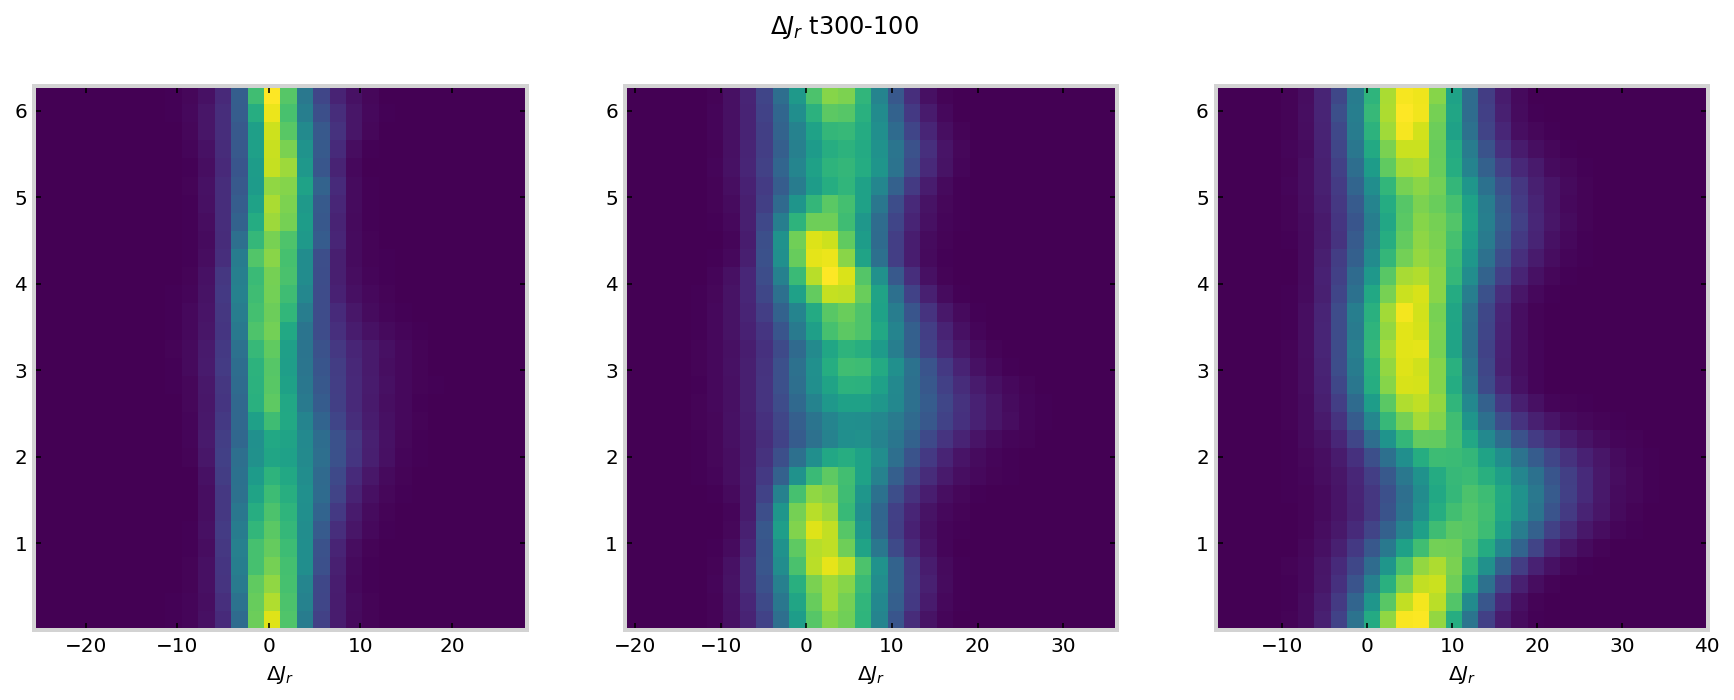

In [38]:
fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist2d(outer_original300.jr[outer_inner] - outer100.jr[outer_inner], 
              outer100.theta_phi[outer_inner], 
              bins=30)
axs[0].set_xlabel(r'$\Delta J_r$')

axs[1].hist2d(outer_original300.jr[outer_middle] - outer100.jr[outer_middle], 
              outer_original300.theta_phi[outer_middle], bins=30)
axs[1].set_xlabel(r'$\Delta J_r$')

axs[2].hist2d(outer_original300.jr[outer_outer] - outer100.jr[outer_outer], outer100.theta_phi[outer_outer], bins=30)
axs[2].set_xlabel(r'$\Delta J_r$')
plt.suptitle(r'$\Delta J_r$ t300-100')
plt.show()

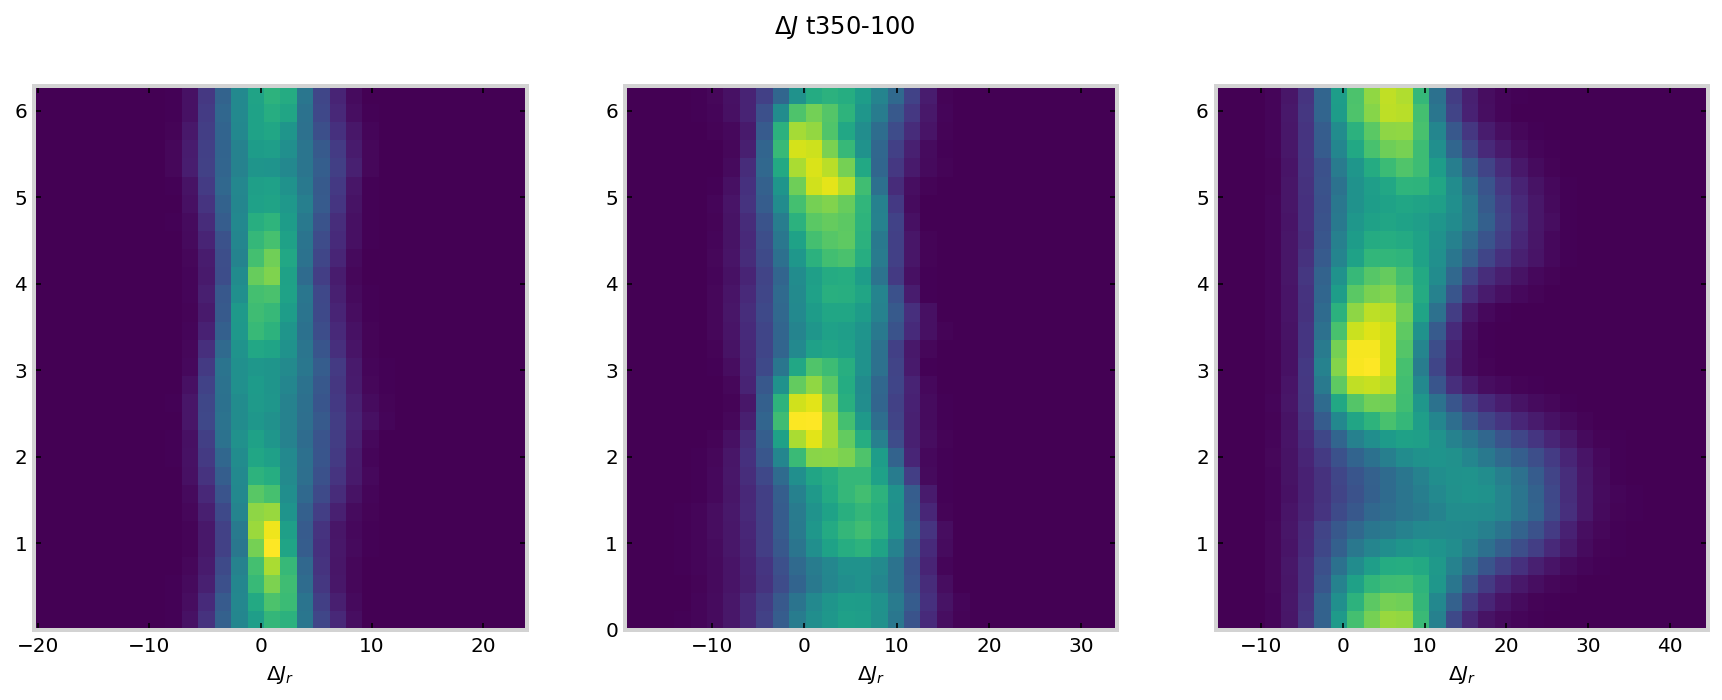

In [39]:
fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist2d(outer_original350.jr[outer_inner] - outer100.jr[outer_inner], 
              outer100.theta_phi[outer_inner], 
              bins=30)
axs[0].set_xlabel(r'$\Delta J_r$')

axs[1].hist2d(outer_original350.jr[outer_middle] - outer100.jr[outer_middle], 
              outer_original350.theta_phi[outer_middle], bins=30)
axs[1].set_xlabel(r'$\Delta J_r$')

axs[2].hist2d(outer_original350.jr[outer_outer] - outer100.jr[outer_outer], outer100.theta_phi[outer_outer], bins=30)
axs[2].set_xlabel(r'$\Delta J_r$')
plt.suptitle(r'$\Delta J$ t350-100')
plt.show()

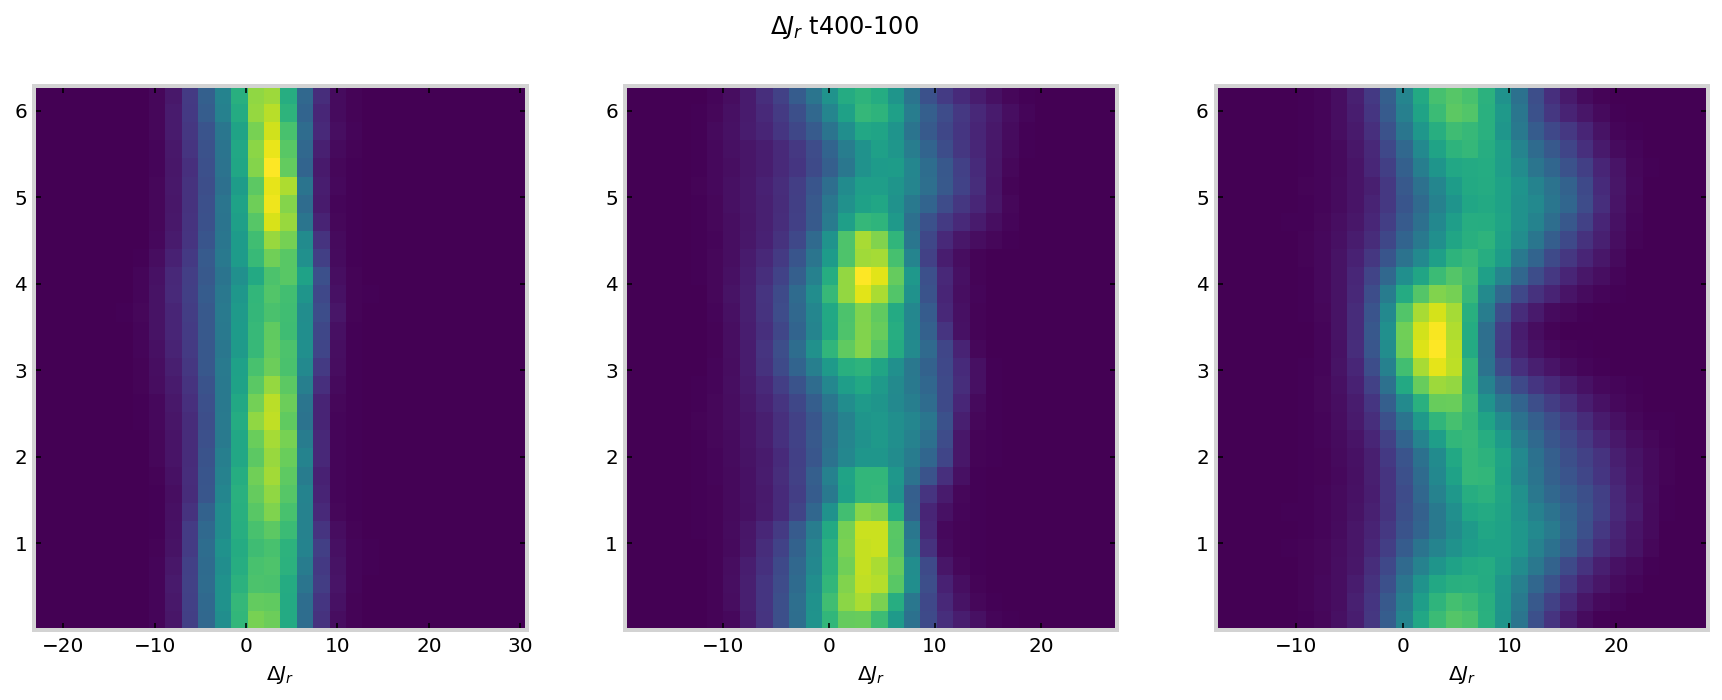

In [40]:
fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].hist2d(outer_original400.jr[outer_inner] - outer100.jr[outer_inner], 
              outer100.theta_phi[outer_inner], 
              bins=30)
axs[0].set_xlabel(r'$\Delta J_r$')

axs[1].hist2d(outer_original400.jr[outer_middle] - outer100.jr[outer_middle], 
              outer_original400.theta_phi[outer_middle], bins=30)
axs[1].set_xlabel(r'$\Delta J_r$')

axs[2].hist2d(outer_original400.jr[outer_outer] - outer100.jr[outer_outer], outer100.theta_phi[outer_outer], bins=30)
axs[2].set_xlabel(r'$\Delta J_r$')
plt.suptitle(r'$\Delta J_r$ t400-100')
plt.show()

## Splitting Up Action Histograms by $J_{\phi}$ bins

In [ ]:
outer_inner = (outer100.jphi < 2100)
outer_middle = (outer100.jphi > 2450) & (outer100.jphi < 2550)
outer_outer = (outer100.jphi > 2900)

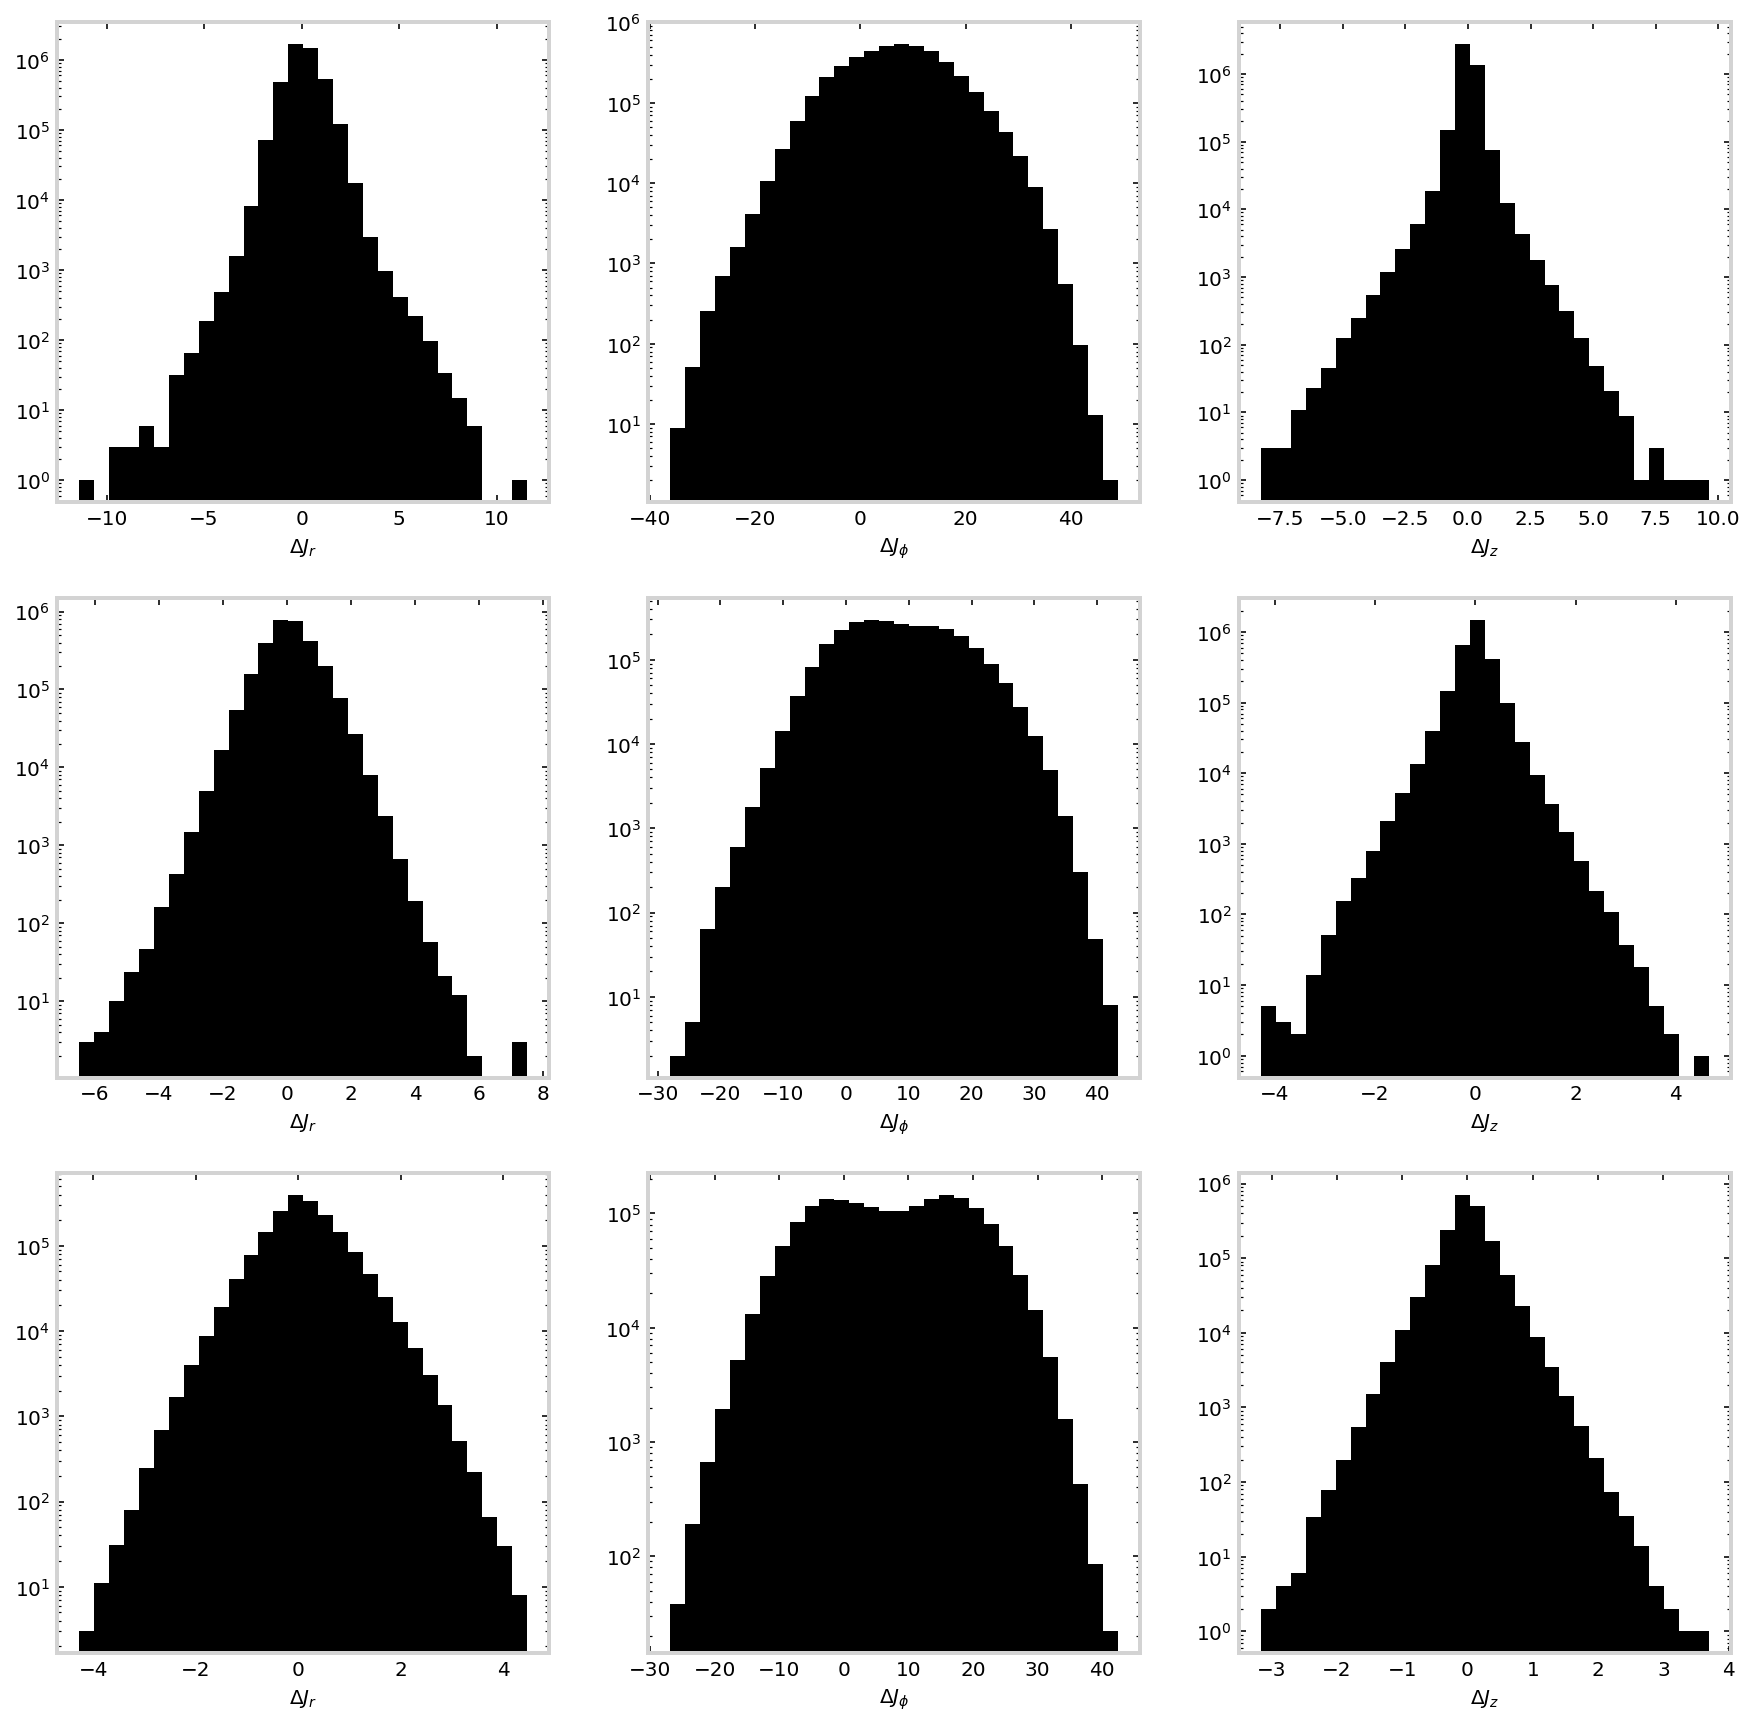

In [50]:
fig, axs = plt.subplots (3,3, figsize=(15,15))

axs[0,0].hist(outer_original250.jr[outer_inner] - outer100.jr[outer_inner], bins=30, color='k')
axs[0,1].hist(outer_original250.jphi[outer_inner] - outer100.jphi[outer_inner], bins=30, color='k')
axs[0,2].hist(outer_original250.jz[outer_inner] - outer100.jz[outer_inner], bins=30, color='k')

axs[1,0].hist(outer_original250.jr[outer_middle] - outer100.jr[outer_middle], bins=30, color='k')
axs[1,1].hist(outer_original250.jphi[outer_middle] - outer100.jphi[outer_middle], bins=30, color='k')
axs[1,2].hist(outer_original250.jz[outer_middle] - outer100.jz[outer_middle], bins=30, color='k')

axs[2,0].hist(outer_original250.jr[outer_outer] - outer100.jr[outer_outer], bins=30, color='k')
axs[2,1].hist(outer_original250.jphi[outer_outer] - outer100.jphi[outer_outer], bins=30, color='k')
axs[2,2].hist(outer_original250.jz[outer_outer] - outer100.jz[outer_outer], bins=30, color='k')

for i in range(3):
    axs[i,0].set_xlabel(r'$\Delta J_r$')
    axs[i,1].set_xlabel(r'$\Delta J_\phi$')
    axs[i,2].set_xlabel(r'$\Delta J_z$')
    for j in range(3):
        axs[i,j].set_yscale('log')

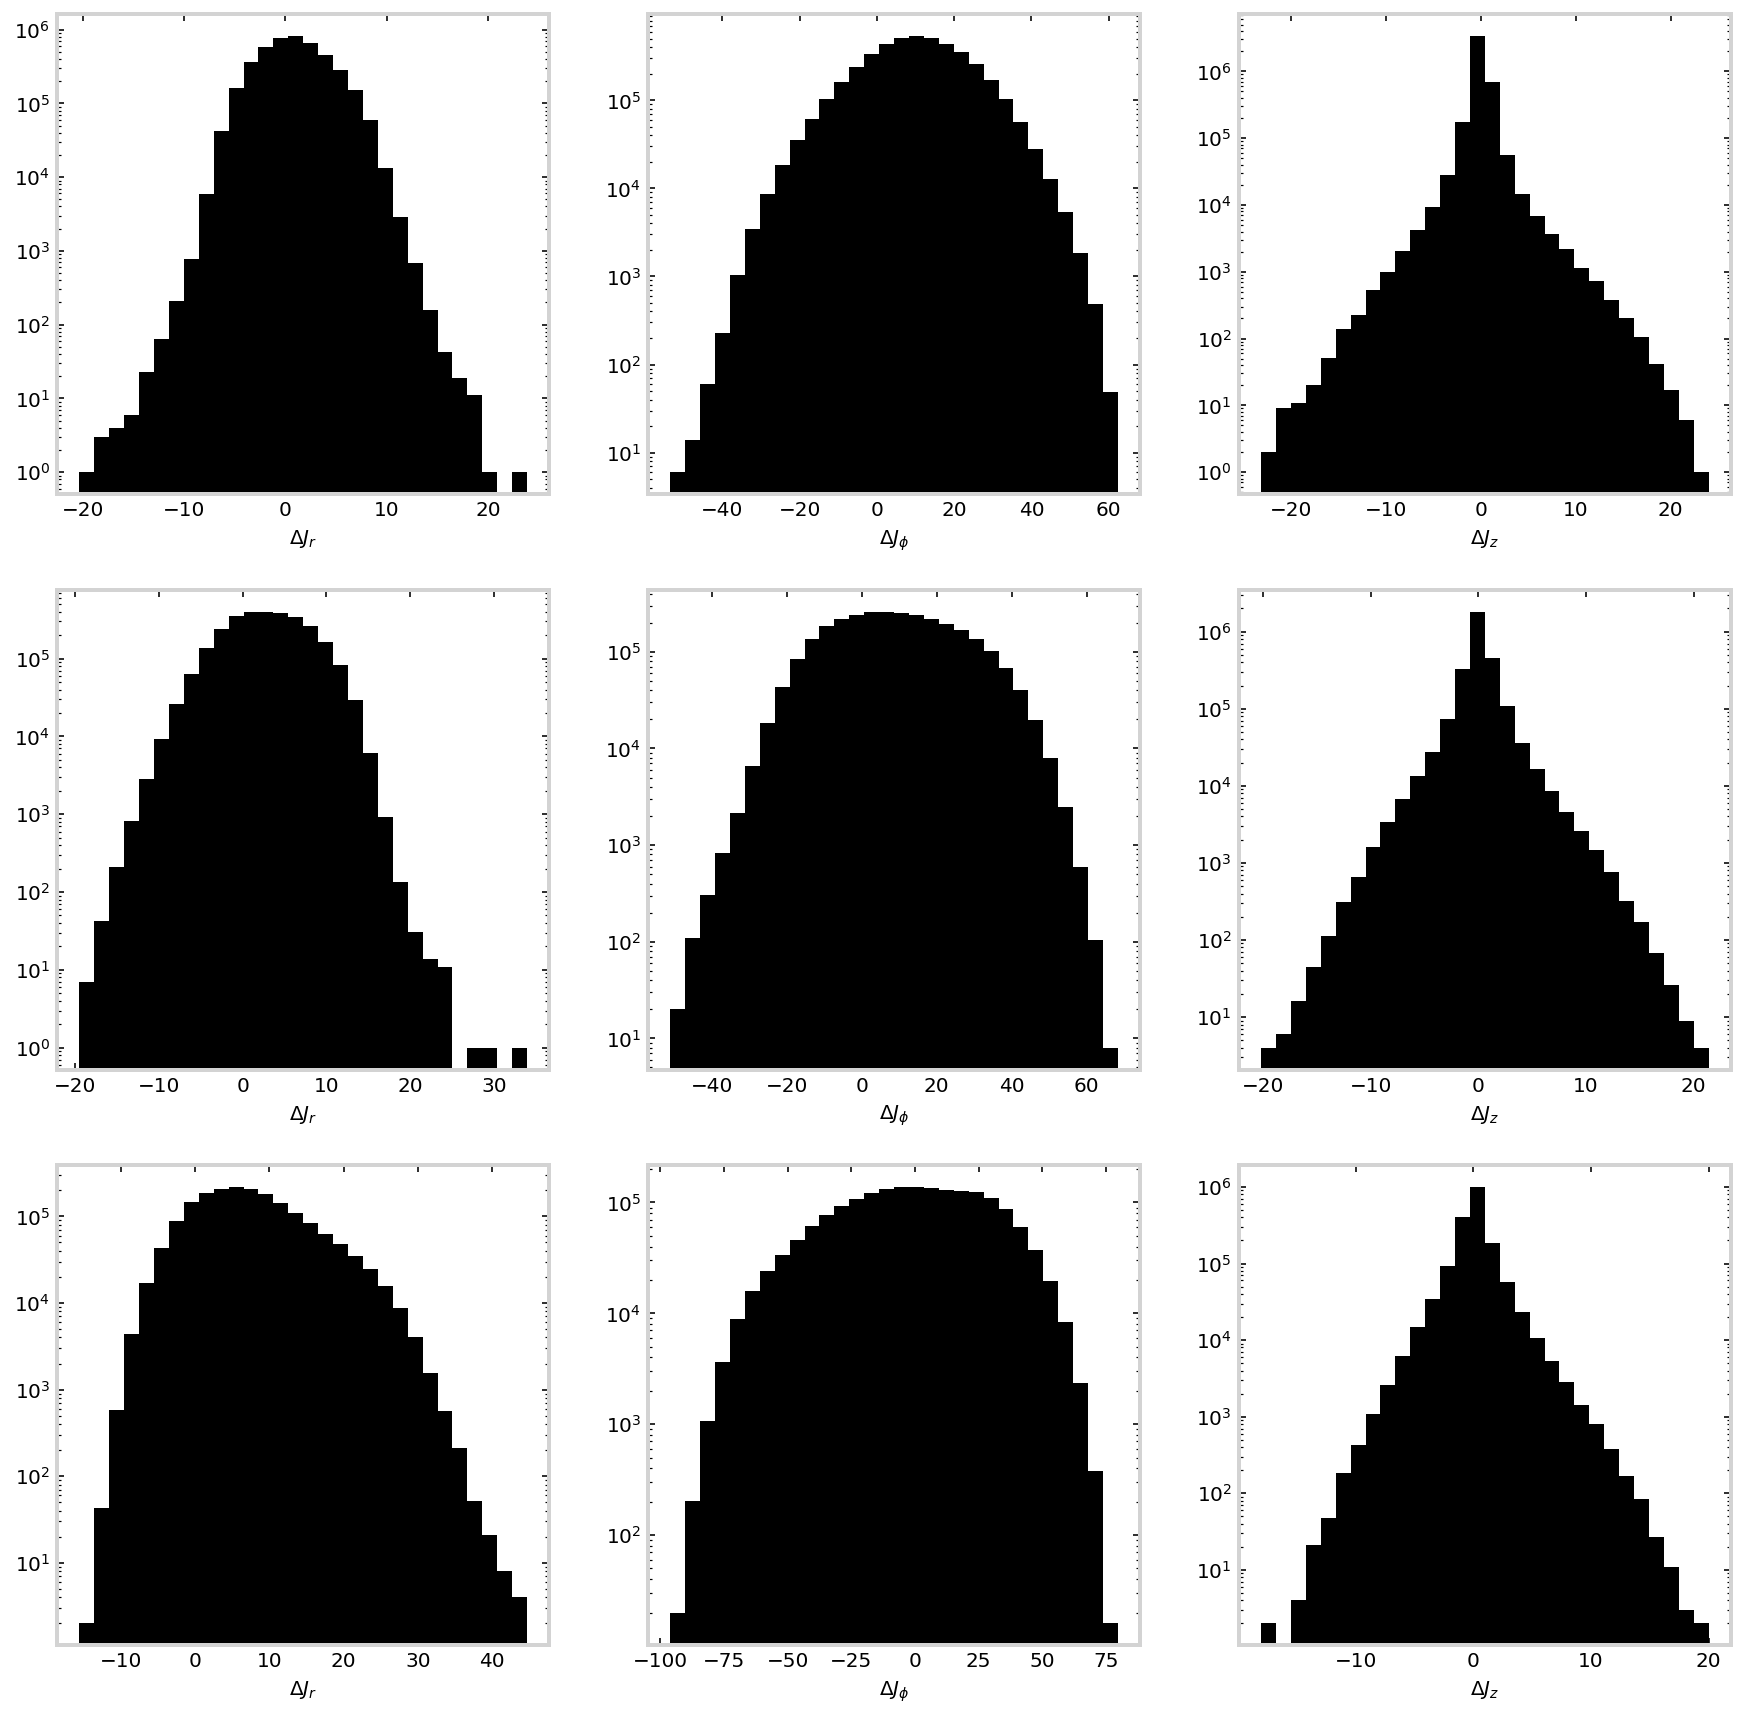

In [51]:
fig, axs = plt.subplots (3,3, figsize=(15,15))

axs[0,0].hist(outer_original350.jr[outer_inner] - outer100.jr[outer_inner], bins=30, color='k')
axs[0,1].hist(outer_original350.jphi[outer_inner] - outer100.jphi[outer_inner], bins=30, color='k')
axs[0,2].hist(outer_original350.jz[outer_inner] - outer100.jz[outer_inner], bins=30, color='k')

axs[1,0].hist(outer_original350.jr[outer_middle] - outer100.jr[outer_middle], bins=30, color='k')
axs[1,1].hist(outer_original350.jphi[outer_middle] - outer100.jphi[outer_middle], bins=30, color='k')
axs[1,2].hist(outer_original350.jz[outer_middle] - outer100.jz[outer_middle], bins=30, color='k')

axs[2,0].hist(outer_original350.jr[outer_outer] - outer100.jr[outer_outer], bins=30, color='k')
axs[2,1].hist(outer_original350.jphi[outer_outer] - outer100.jphi[outer_outer], bins=30, color='k')
axs[2,2].hist(outer_original350.jz[outer_outer] - outer100.jz[outer_outer], bins=30, color='k')

for i in range(3):
    axs[i,0].set_xlabel(r'$\Delta J_r$')
    axs[i,1].set_xlabel(r'$\Delta J_\phi$')
    axs[i,2].set_xlabel(r'$\Delta J_z$')
    for j in range(3):
        axs[i,j].set_yscale('log')